# Adaptive NIDS → Reinforcement-Learning IPS: Full Codebase Lab

This notebook is the single entry point for the project. Each section explains **why the cell exists**, runs the real repository code, and interprets what the current output proves. It distinguishes saved historical model evidence, live tests, simulator evidence, dataset-backed observations, and cyber-range work that is still missing.

## 0 — Runtime controls

`RUN_HEAVY=False` keeps the notebook suitable for a quick demonstration. Set it to `True` for more DQN episodes, five seeds, and the full pytest suite. Training and evaluation seeds remain separate.

In [1]:
from pathlib import Path
import inspect, json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
if REPO.name == 'notebooks': REPO = REPO.parent
SRC = REPO / 'src'
if str(SRC) not in sys.path: sys.path.insert(0, str(SRC))
RUN_HEAVY = False
SEED = 42
OUTPUT = REPO / 'results' / 'notebook_ips_lab'
OUTPUT.mkdir(parents=True, exist_ok=True)
print({'repo': str(REPO), 'python': sys.version.split()[0], 'run_heavy': RUN_HEAVY, 'output': str(OUTPUT)})

{'repo': "/Users/hexenmeister/Library/Mobile Documents/com~apple~CloudDocs/Desktop/don't delete update/codes/network-intrusion-detection-ml", 'python': '3.14.6', 'run_heavy': False, 'output': "/Users/hexenmeister/Library/Mobile Documents/com~apple~CloudDocs/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab"}


## 1 — Dynamic project inventory

This calls the same reporting code as `src/project_benchmark.py`. It discovers dependencies, local datasets, implemented tracks, saved benchmarks, feature representations, and IPS baselines from the current checkout. Missing data remains visible rather than being silently replaced.

In [2]:
import project_benchmark as PB
report = PB.build_report(full=False, episodes=200 if RUN_HEAVY else 50, seed=SEED, output_dir=OUTPUT / 'benchmark')
display(pd.DataFrame(report['datasets']))
display(pd.DataFrame(report['features']))
display(pd.DataFrame(report['tracks']))
print('Artifact counts:', report['artifact_counts'])

,dataset,role,status,limitation
0,NSL-KDD,Controlled baseline for every new method.,available,None for current NSL-KDD baseline; temporal cl...
1,CICIoT2023 dev parquet,Fast modern IoT dev sample for quality checks ...,missing,Do not treat dev-sample results as full offici...
2,CICIoT2023 raw CSV,"Primary modern IoT supervised dataset: binary,...",blocked_missing_local_files,No full raw CSV modelling or quality claim unt...
3,TON_IoT,"Multimodal SOC/EDR-style track: network, IoT t...",blocked_missing_local_files,"No multimodal fusion, host telemetry, or TON_I..."
4,CSE-CIC-IDS2018,Enterprise-scale/day-based drift and chronolog...,blocked_missing_local_files,No enterprise/day-based drift result is valid ...
5,Common NetFlow schema,Cross-dataset generalization using shared NetF...,blocked_missing_local_files,No cross-dataset score is valid without a comm...


,representation,features,details
0,NSL-KDD raw flow,41,3 categorical + 38 numeric; difficulty excluded
1,Adaptive IPS state,7,"threat probability, anomaly, attack stage, com..."
2,CICIoT2023,46,published expected model features; local parqu...


,track,status,evidence
0,Leakage-safe preprocessing,PROVEN,src/preprocess.py + tests
1,Supervised reference models,PROVEN,results/reference_track.csv
2,RF/LightGBM official split,PROVEN,results/metrics.md
3,Weighted/unweighted MLP,PROVEN,results/stability.md
4,Threshold tuning,PROVEN,results/threshold_ablation.csv
5,Normal-only anomaly detection,PROVEN,results/anomaly_detection.csv
6,Semi-supervised learning,PROVEN,results/semi_supervised.csv
7,Online partial-fit proxy,PARTIAL,not chronological drift
8,CICIoT2023 supervised dev,PARTIAL,"random dev split, not full raw CSV"
9,Adaptive IPS environment,PROVEN,src/ips + safety tests


Artifact counts: {'figures': 43, 'csv_results': 26, 'markdown_results': 19, 'test_files': 23}


**How to read the output:** `PROVEN` means code plus saved evidence exists; `PARTIAL` means the method exists but the data/protocol cannot support the full claim; `BLOCKED` identifies the exact missing local data. Dataset availability and saved-result availability are different—committed metrics can exist while raw files are intentionally gitignored.

## 2 — Model training status and metric mathematics

This section shows where every model fitted, how it was selected, where it was evaluated, and the command that reproduces it. The formulas prevent incompatible leaderboards—for example, CICIoT random-dev macro-F1 must not be ranked directly against NSL-KDD official-shift macro-F1.

In [3]:
display(pd.DataFrame(report['model_training']))
display(pd.DataFrame(report['metric_definitions']))
display(pd.DataFrame(report['saved_benchmarks']))

,dataset_task,models,status,fit_selection,evaluation,run
0,NSL-KDD binary + 5-class,"Dummy, LogReg, RF, ExtraTrees, HistGB, LightGBM",TRAINED / SAVED,official train; class balancing; train-only va...,official KDDTest+; macro-F1 + per-class recall,.venv/bin/python src/reference_track.py
1,NSL-KDD binary + 5-class,MLP unweighted + class-weighted,TRAINED / 5-SEED,official train; internal early-stopping valida...,official KDDTest+; macro-F1 and rare-family re...,.venv/bin/python src/train_mlp.py
2,NSL-KDD anomaly,"IsolationForest, LOF, KMeans distance",TRAINED / SAVED,normal training rows only; train-normal quanti...,official KDDTest+ attack/family recall,.venv/bin/python src/anomaly_detection.py
3,CICIoT2023 dev binary + category,"Dummy, LogReg, RF, HistGB, LightGBM",TRAINED / DEV ONLY,stratified 200k train sample; random dev parti...,full dev test partition; not raw/temporal evid...,.venv/bin/python src/ciciot2023_baselines.py
4,Adaptive IPS simulated episodes,"Allow-only, rule-based, aggressive",RUN LIVE IN THIS REPORT,no fitting; identical seeded scenarios,"containment, compromise, disruption, false pre...",.venv/bin/python src/project_benchmark.py
5,Adaptive IPS simulated episodes,Masked Double DQN,IMPLEMENTED / SMOKE WITH --full,training seed range; disjoint validation seed ...,safety-first checkpoint ordering; simulator ev...,.venv/bin/python src/project_benchmark.py --full


,metric,calculation,use
0,accuracy,correct predictions / all predictions,secondary under imbalance
1,per-class recall,TP / (TP + FN) for that class,how many attacks of each family are caught
2,macro-F1,unweighted mean of each class F1; F1=2PR/(P+R),primary classifier comparison
3,weighted-F1,class F1 weighted by class support,overall volume-weighted quality
4,ROC-AUC,area under TPR versus FPR across thresholds,binary ranking; can flatter imbalance
5,PR-AUC,area under precision versus recall,preferred binary ranking under imbalance
6,containment rate,contained attack episodes / attack episodes,IPS prevention outcome
7,compromise rate,compromised attack episodes / attack episodes,lower is better; first checkpoint criterion
8,false prevention,disruptive actions in benign episodes / episodes,availability/safety cost
9,mean return,mean sum of transition rewards per episode,RL objective; never interpreted alone


,track,artifact,status,best_macro_f1,best_method
0,NSL-KDD reference,results/reference_track.csv,missing,NaN,NaN
1,CICIoT2023 dev,results/ciciot2023_baselines.csv,available,0.856267,RandomForest (balanced)
2,Threshold ablation,results/threshold_ablation.csv,available,0.823031,HistGB_balanced
3,Anomaly detection,results/anomaly_detection.csv,available,0.841344,KMeans_distance
4,Semi-supervised,results/semi_supervised.csv,available,0.754244,labelled_only_logreg
5,Online proxy,results/online_learning.csv,available,0.764180,SGD_log_loss_balanced
6,Neural ablation,results/neural_ablation.csv,available,0.775930,NaN


## 3 — Inspect the real implementation

Rather than duplicating source code in notebook cells, this dynamically displays the current implementations. Changes to the Python modules therefore appear here automatically.

In [4]:
from IPython.display import display
from ips.environment import AdaptiveIpsEnv
from ips.actions import valid_action_mask
from ips.train_dqn import optimize_batch
from ips.dataset import build_episodes, split_episodes_by_group
for title, obj in [('Safety mask', valid_action_mask), ('IPS environment step', AdaptiveIpsEnv.step), ('Masked Double-DQN update', optimize_batch), ('Dataset episode builder', build_episodes), ('Group-safe split', split_episodes_by_group)]:
    print('\n###', title)
    print(inspect.getsource(obj))


### Safety mask
def valid_action_mask(
    threat_probability: float,
    critical_service: bool,
    host_compromise: float,
) -> np.ndarray:
    """Return a boolean mask that prevents unjustified disruptive actions.

    The mask is a hard safety layer, independent of what an RL policy proposes.
    Critical hosts require stronger evidence before port blocking or isolation.
    """
    if not 0.0 <= threat_probability <= 1.0:
        raise ValueError("threat_probability must be in [0, 1]")
    if not 0.0 <= host_compromise <= 1.0:
        raise ValueError("host_compromise must be in [0, 1]")

    mask = np.ones(len(IpsAction), dtype=bool)
    mask[IpsAction.TEMP_BLOCK_SOURCE] = threat_probability >= 0.60
    mask[IpsAction.BLOCK_DESTINATION_PORT] = (
        threat_probability >= (0.90 if critical_service else 0.70)
    )
    mask[IpsAction.ISOLATE_HOST] = (
        host_compromise >= (0.90 if critical_service else 0.70)
        and threat_probability >= 0.80
    )
    return mask



## 4 — Live verification

The tests verify schema validation, train/test leakage rules, safety masking, deterministic transitions, Bellman targets, replay memory, checkpoint artifacts, and multi-seed final-test plumbing. Data-dependent tests skip honestly when raw datasets are absent.

In [5]:
test_targets = [] if RUN_HEAVY else ['tests/test_ips_environment.py', 'tests/test_ips_training.py', 'tests/test_ips_dataset.py', 'tests/test_project_benchmark.py']
command = [sys.executable, '-m', 'pytest', '-p', 'no:cacheprovider', *test_targets]
tests = subprocess.run(command, cwd=REPO, text=True, capture_output=True)
print(tests.stdout); print(tests.stderr)
assert tests.returncode == 0, 'Verification failed—inspect the output above before trusting later cells.'

..........................                                               [100%]
26 passed in 1.01s




## 5 — Prevention actions, safety masks, and one episode

The detector supplies risk estimates; the policy selects an intervention. A hard mask outside the learned policy prevents unjustified source blocks, port blocks, or host isolation. This cell prints each transition so reward terms and action overrides are visible.

In [6]:
from ips.actions import IpsAction
from ips.policies import rule_based_policy
env = AdaptiveIpsEnv(max_steps=12, seed=SEED)
obs, info = env.reset(seed=SEED, attack_present=True, critical_service=True)
trajectory = []
while True:
    action = rule_based_policy(obs, info['action_mask'])
    result = env.step(action)
    trajectory.append({'threat': obs.threat_probability, 'stage': obs.attack_stage, 'proposed': action.name, 'executed': result.info['executed_action'], 'masked': result.info['action_was_masked'], 'reward': result.reward, 'contained': result.info['contained'], 'compromised': result.info['compromised']})
    obs, info = result.observation, {'action_mask': result.info['action_mask']}
    if result.terminated or result.truncated or result.info['contained']: break
display(pd.DataFrame(trajectory))
print('Interpretation: positive reward comes from containment; compromise and critical-service disruption are strongly penalized.')

,threat,stage,proposed,executed,masked,reward,contained,compromised
0,0.594377,0.25,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
1,0.413917,0.25,MONITOR,MONITOR,False,-0.55,False,False
2,0.568656,0.25,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
3,0.575282,0.25,RATE_LIMIT,RATE_LIMIT,False,-0.50,False,False
4,0.719500,0.50,DROP_FLOW,DROP_FLOW,False,-0.50,False,False
5,0.675211,0.50,DROP_FLOW,DROP_FLOW,False,-0.50,False,False
6,0.655734,0.50,DROP_FLOW,DROP_FLOW,False,8.00,True,False


Interpretation: positive reward comes from containment; compromise and critical-service disruption are strongly penalized.


## 6 — Required policy baselines

RL is credible only if it beats simple policies. All policies below receive identical seeded scenarios. Containment and compromise are conditional on attack episodes; disruption exposes policies that appear secure only by blocking everything.

,episodes,attack_episodes,benign_episodes,mean_return,return_std,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,masked_actions_per_episode,mean_steps
policy,,,,,,,,,,,
allow_only,50,26,24,-14.100,13.5643,0.0000,1.0000,0.0,0.00,0.0,26.72
rule_based,50,26,24,2.789,5.8913,0.9615,0.0385,0.0,1.06,0.0,25.12
aggressive,50,26,24,-34.360,43.8501,1.0000,0.0000,9.6,10.36,0.0,10.36


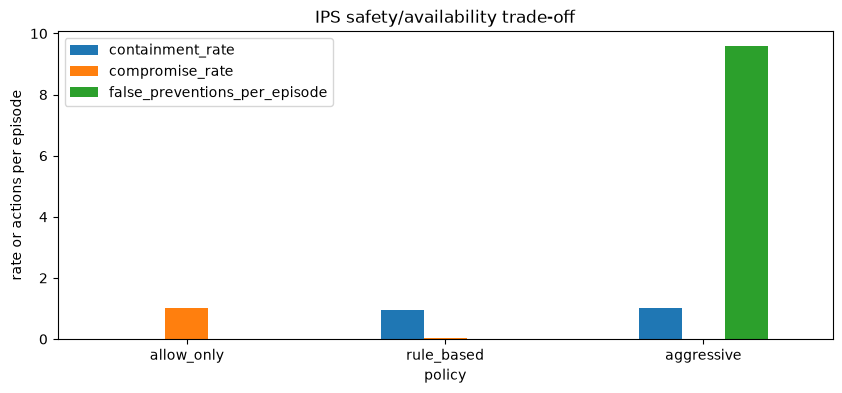

In [7]:
baseline_df = pd.DataFrame(report['ips_baselines']).set_index('policy')
display(baseline_df.round(4))
baseline_df[['containment_rate', 'compromise_rate', 'false_preventions_per_episode']].plot.bar(figsize=(10,4), title='IPS safety/availability trade-off')
plt.ylabel('rate or actions per episode'); plt.xticks(rotation=0); plt.show()

## 7 — Train masked Double DQN

The online network selects the best valid next action and the target network evaluates it. Replay memory breaks temporal correlation; Huber loss limits sensitivity to large penalties; the target network updates periodically. Validation seeds never overlap training seeds. This is still simulator training.

In [8]:
from ips.dqn import DqnConfig
from ips.train_dqn import TrainConfig, train
dqn_config = DqnConfig(hidden_dim=64, batch_size=64, replay_capacity=10000, warmup_steps=128, target_update_steps=250, epsilon_decay_steps=5000)
train_config = TrainConfig(episodes=1000 if RUN_HEAVY else 100, validation_interval=100 if RUN_HEAVY else 25, validation_episodes=300 if RUN_HEAVY else 50)
trained = train(dqn_config, train_config, seed=SEED, output_dir=OUTPUT / 'simulator_dqn')
display(pd.DataFrame([trained.best_validation.to_dict()]))
print('Checkpoint:', trained.best_checkpoint, 'steps:', trained.total_steps, 'updates:', trained.updates)

,episodes,attack_episodes,benign_episodes,mean_return,return_std,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,masked_actions_per_episode,mean_steps
0,50,20,30,3.08,3.779365,1.0,0.0,0.0,0.62,0.0,30.64


Checkpoint: /Users/hexenmeister/Library/Mobile Documents/com~apple~CloudDocs/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab/simulator_dqn/dqn_best.pt steps: 2207 updates: 2080


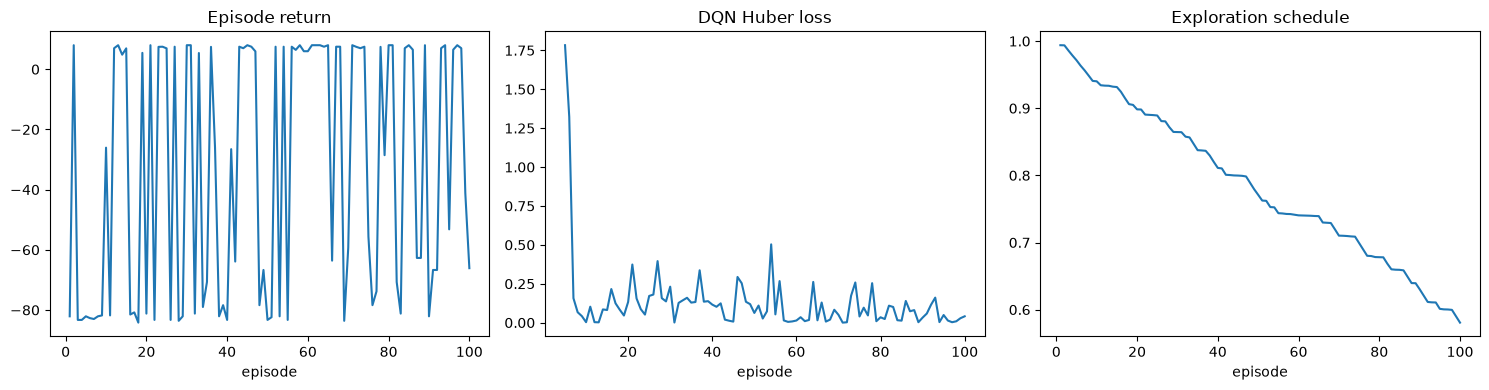

Interpretation: loss need not decrease monotonically in RL. Prevention metrics on disjoint scenarios decide the checkpoint.


In [9]:
history = pd.read_json(trained.history_path, lines=True)
fig, axes = plt.subplots(1, 3, figsize=(15,4))
history.plot(x='episode', y='episode_return', ax=axes[0], title='Episode return', legend=False)
history.dropna(subset=['mean_loss']).plot(x='episode', y='mean_loss', ax=axes[1], title='DQN Huber loss', legend=False)
history.plot(x='episode', y='epsilon', ax=axes[2], title='Exploration schedule', legend=False)
plt.tight_layout(); plt.show()
print('Interpretation: loss need not decrease monotonically in RL. Prevention metrics on disjoint scenarios decide the checkpoint.')

## 8 — Construct dataset-backed episodes

If `data/ips_events/events.parquet` exists, it is loaded. It must contain timestamps, campaign/group IDs, labels, criticality, attack stage, anomaly scores, and **out-of-fold detector probabilities**. Otherwise this cell creates an explicitly synthetic fixture to demonstrate the contract—it never labels that fixture as dataset evidence.

In [10]:
from ips.dataset import build_episodes, split_episodes_by_group, assert_group_disjoint
event_path = REPO / 'data' / 'ips_events' / 'events.parquet'
if event_path.exists():
    events = pd.read_parquet(event_path); evidence_kind = 'REAL DATASET-BACKED OBSERVATIONS'
else:
    rng = np.random.default_rng(SEED); rows=[]
    family_cycle = ['normal','DoS','Probe','BruteForce','Exploitation','R2L','U2R']
    for group in range(350 if RUN_HEAVY else 140):
        family = family_cycle[group % len(family_cycle)]; attack = family != 'normal'
        for step in range(6):
            rows.append({'episode_id': f'ep-{group}', 'group_id': f'campaign-{group}', 'timestamp': float(step), 'threat_probability': float(np.clip(rng.normal(0.72 if attack else 0.15, .1),0,1)), 'anomaly_score': float(np.clip(rng.normal(0.75 if attack else 0.2,.1),0,1)), 'attack_present': attack, 'attack_stage': (step+1)/6 if attack else 0.0, 'critical_service': group%5==0, 'attack_family': family})
    events = pd.DataFrame(rows); evidence_kind = 'SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE'
episodes = build_episodes(events)
splits = split_episodes_by_group(episodes, seed=SEED)
assert_group_disjoint(splits)
print(evidence_kind)
display(events.head())
display(pd.DataFrame([{'split': name, 'episodes': len(value), 'groups': len({e.group_id for e in value}), 'attack_episodes': sum(e.contains_attack for e in value)} for name, value in [('train', splits.train), ('validation', splits.validation), ('final_test', splits.test)]]))

SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE


,episode_id,group_id,timestamp,threat_probability,anomaly_score,attack_present,attack_stage,critical_service,attack_family
0,ep-0,campaign-0,0.0,0.180472,0.096002,False,0.0,True,normal
1,ep-0,campaign-0,1.0,0.225045,0.294056,False,0.0,True,normal
2,ep-0,campaign-0,2.0,0.000000,0.069782,False,0.0,True,normal
3,ep-0,campaign-0,3.0,0.162784,0.168376,False,0.0,True,normal
4,ep-0,campaign-0,4.0,0.148320,0.114696,False,0.0,True,normal


,split,episodes,groups,attack_episodes
0,train,98,98,85
1,validation,21,21,16
2,final_test,21,21,19


## 9 — Multi-seed dataset-backed experiment

Each seed independently trains on training episodes. Validation chooses that seed's checkpoint. The final-test split is then evaluated once. Mean ± standard deviation is reported across seeds. Observations may be real; action outcomes remain counterfactual until cyber-range interventions replace them.

In [11]:
from ips.dataset_experiment import DatasetTrainConfig, run_multi_seed
seeds = (42,43,44,45,46) if RUN_HEAVY else (42,43,44)
dataset_dqn = DqnConfig(hidden_dim=32, batch_size=16, replay_capacity=2000, warmup_steps=32, target_update_steps=50, epsilon_decay_steps=1000)
dataset_training = DatasetTrainConfig(episodes=500 if RUN_HEAVY else 40, validation_interval=100 if RUN_HEAVY else 20)
per_seed = run_multi_seed(splits, seeds=seeds, dqn=dataset_dqn, training=dataset_training, output_dir=OUTPUT / 'dataset_multi_seed')
display(per_seed.round(4))
summary = per_seed.drop(columns='seed').agg(['mean','std']).T
display(summary.round(4))
print('Evidence label:', evidence_kind)

,seed,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,mean_return,return_std
0,42,21,19,1.0,0.0,0.5714,1.8095,4.7857,9.3447
1,43,21,19,1.0,0.0,0.0000,1.1905,7.0000,2.2991
2,44,21,19,1.0,0.0,0.0000,1.1905,7.0952,2.3177


,mean,std
episodes,21.0000,0.0000
attack_episodes,19.0000,0.0000
containment_rate,1.0000,0.0000
compromise_rate,0.0000,0.0000
false_preventions_per_episode,0.1905,0.3299
disruptive_actions_per_episode,1.3968,0.3574
mean_return,6.2937,1.3068
return_std,4.6538,4.0624


Evidence label: SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE


## 10 — Candidate model discovery: measured versus theoretical

The executed candidate set varies DQN capacity, horizon discount, learning rate, batch size, and target-update frequency because these directly affect discrete sequential control. Masked PPO, constrained PPO, and a contextual bandit are listed separately as theoretically justified but **not executed** in this notebook. Quantization and context length are not relevant here: this is a small FP32 control network, not a language model.

In [12]:
from ips.experiment_analysis import DEFAULT_CANDIDATES, THEORETICAL_CANDIDATES, parameter_count, factorial_candidates
executed_catalog = pd.DataFrame([{**c.__dict__, 'parameters': parameter_count(c), 'quantization': 'FP32', 'executed': True} for c in DEFAULT_CANDIDATES])
theory_catalog = pd.DataFrame(THEORETICAL_CANDIDATES)
display(executed_catalog)
display(theory_catalog)
print('Interpretation: DQN variants can run comfortably on CPU because even the largest tested network has only thousands of parameters. PPO remains a recommendation, not a benchmark result.')

,name,hidden_dim,gamma,learning_rate,batch_size,target_update_steps,episodes,parameters,quantization,executed
0,DQN-small-fast,16,0.95,0.0010,16,50,60,519,FP32,True
1,DQN-small-long-horizon,16,0.99,0.0010,16,50,60,519,FP32,True
2,DQN-balanced,32,0.99,0.0010,32,75,60,1543,FP32,True
3,DQN-low-lr,32,0.99,0.0003,32,75,60,1543,FP32,True
4,DQN-large,64,0.99,0.0010,32,100,60,5127,FP32,True
5,DQN-large-batch,64,0.99,0.0010,64,100,60,5127,FP32,True


,model,executed,why,strength,weakness,environment_fit
0,Masked PPO,False,stable policy-gradient comparison with the sam...,less sensitive than DQN to Q-value scale and r...,less sample-efficient; needs a vectorized envi...,realistic after dataset episodes and reward se...
1,Constrained PPO,False,separates prevention reward from explicit disr...,directly models an availability/safety budget,more complex optimization and multiplier tuning,recommended final simulator/cyber-range policy
2,Contextual bandit,False,tests whether sequential credit assignment is ...,"simple, fast, highly interpretable baseline",cannot value delayed containment or attack pro...,strong additional baseline


Interpretation: DQN variants can run comfortably on CPU because even the largest tested network has only thousands of parameters. PPO remains a recommendation, not a benchmark result.


## 11 — Controlled multi-configuration benchmark

Every candidate uses the same campaign-disjoint split and final-test episodes. Runtime is wall-clock time, checkpoint memory is serialized model size, and peak memory is measured with Python `tracemalloc`—it does not include every native allocator, so it is a comparative development metric rather than total process RAM.

In [13]:
from ips.experiment_analysis import benchmark_candidates, add_objective_scores
candidates = factorial_candidates(episodes=120 if RUN_HEAVY else 30)
bench = benchmark_candidates(splits, candidates=candidates, seed=SEED, output_dir=OUTPUT / 'candidate_benchmark')
bench = add_objective_scores(bench)
comparison_cols = ['name','parameters','quantization','checkpoint_mb','peak_python_memory_mb','runtime_s','throughput_steps_s','containment_rate','compromise_rate','false_preventions_per_episode','safety_quality','pareto_optimal']
display(bench[comparison_cols].sort_values('safety_quality', ascending=False).round(4))
print('Result:', bench.loc[bench.safety_quality.idxmax(), 'name'], 'has the highest observed safety quality.')
print('Next implication: inspect whether that gain survives runtime/memory trade-offs and parameter sensitivity before selecting it.')

,name,parameters,quantization,checkpoint_mb,peak_python_memory_mb,runtime_s,throughput_steps_s,containment_rate,compromise_rate,false_preventions_per_episode,safety_quality,pareto_optimal
0,DQN-h16-b16,519,FP32,0.0052,0.2973,0.0422,1467.5787,1.0000,0.0000,0.0000,1.0000,False
1,DQN-h16-b32,519,FP32,0.0052,0.2461,0.0236,2627.9492,1.0000,0.0000,0.0000,1.0000,False
2,DQN-h16-b64,519,FP32,0.0052,0.2463,0.0235,2642.7728,1.0000,0.0000,0.0000,1.0000,True
6,DQN-h64-b16,5127,FP32,0.0228,0.2543,0.0444,1396.1697,1.0000,0.0000,0.0000,1.0000,False
7,DQN-h64-b32,5127,FP32,0.0228,0.2457,0.0253,2448.7781,1.0000,0.0000,0.0000,1.0000,False
8,DQN-h64-b64,5127,FP32,0.0228,0.2454,0.0254,2441.1852,1.0000,0.0000,0.0000,1.0000,False
3,DQN-h32-b16,1543,FP32,0.0091,0.2515,0.0447,1385.9317,1.0000,0.0000,1.4286,0.9286,False
4,DQN-h32-b32,1543,FP32,0.0091,0.2462,0.0345,1796.9257,0.9375,0.0625,0.0000,0.8750,False
5,DQN-h32-b64,1543,FP32,0.0091,0.2465,0.0328,1891.2121,0.9375,0.0625,0.0000,0.8750,False


Result: DQN-h16-b16 has the highest observed safety quality.
Next implication: inspect whether that gain survives runtime/memory trade-offs and parameter sensitivity before selecting it.


## 12 — Visual model comparison and Pareto frontier

A model is Pareto-optimal when no other measured configuration is at least as good in quality, runtime, and checkpoint size while being strictly better in one. Dominated candidates are usually poor follow-up choices unless they contribute stability or an unmeasured operational property.

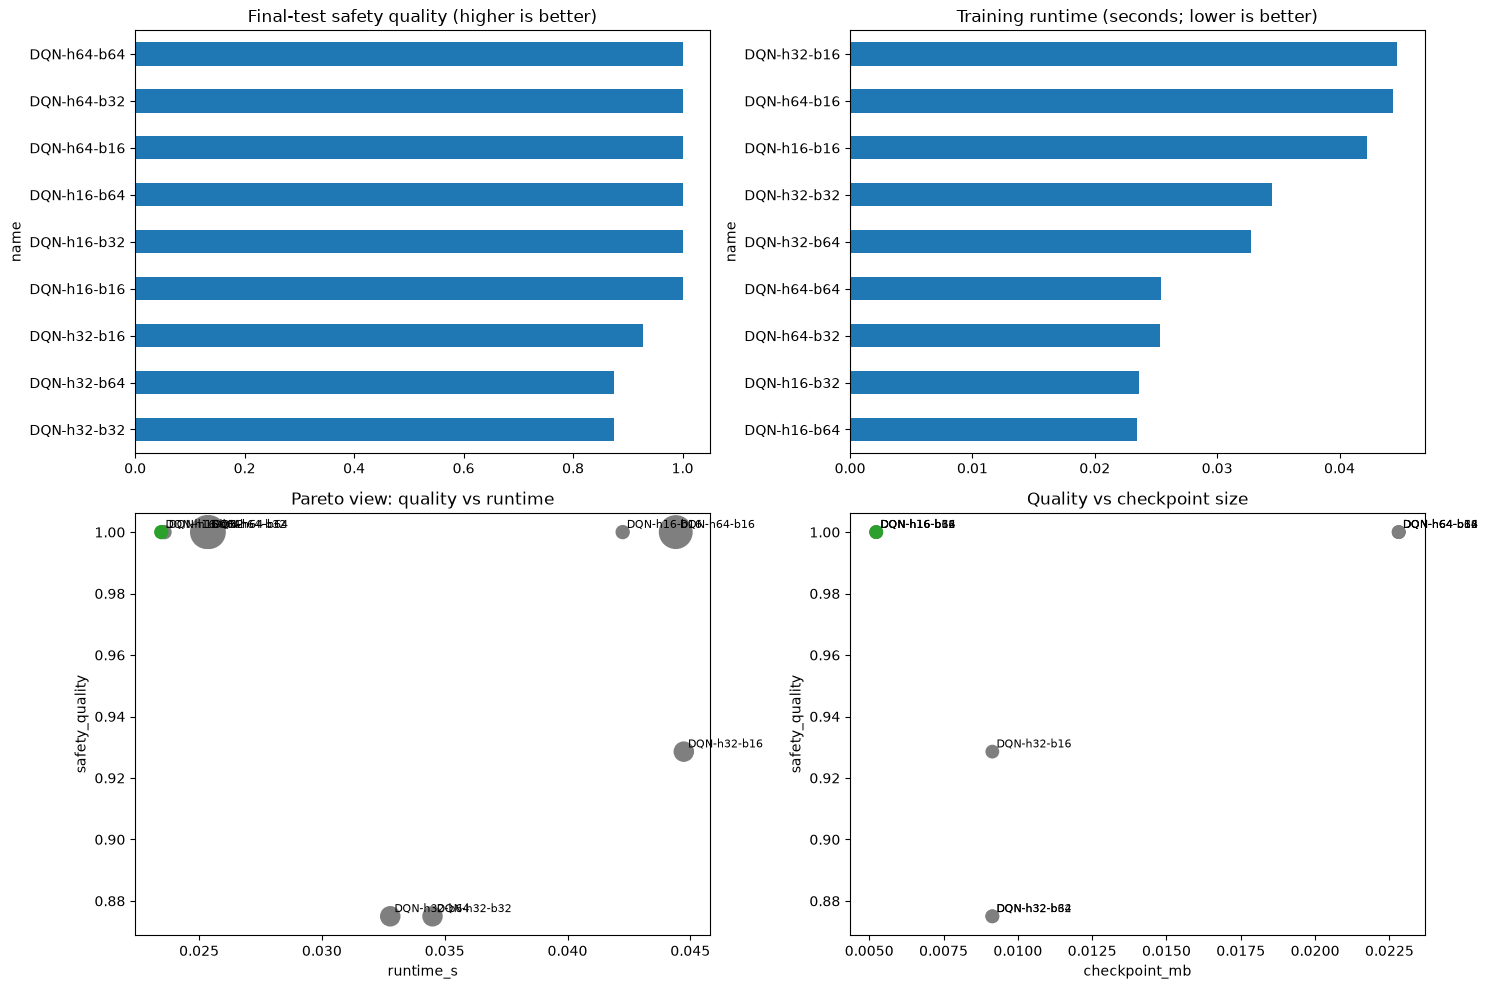

Pareto candidates: DQN-h16-b64


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
bench.sort_values('safety_quality').plot.barh(x='name', y='safety_quality', ax=axes[0,0], legend=False, title='Final-test safety quality (higher is better)')
bench.sort_values('runtime_s').plot.barh(x='name', y='runtime_s', ax=axes[0,1], legend=False, title='Training runtime (seconds; lower is better)')
bench.plot.scatter(x='runtime_s', y='safety_quality', s=bench.parameters/10+35, c=bench.pareto_optimal.map({True:'tab:green',False:'tab:gray'}), ax=axes[1,0], title='Pareto view: quality vs runtime')
bench.plot.scatter(x='checkpoint_mb', y='safety_quality', s=80, c=bench.pareto_optimal.map({True:'tab:green',False:'tab:gray'}), ax=axes[1,1], title='Quality vs checkpoint size')
for ax in (axes[1,0], axes[1,1]):
    for _, r in bench.iterrows(): ax.annotate(r['name'], (r[ax.get_xlabel()], r['safety_quality']), fontsize=8, xytext=(3,3), textcoords='offset points')
plt.tight_layout(); plt.show()
print('Pareto candidates:', ', '.join(bench.loc[bench.pareto_optimal, 'name']))

## 13 — Parameter impact and sensitivity

Spearman correlation measures monotonic association and is appropriate for this small, non-Gaussian grid. It does not establish causality, especially because parameters were not varied in a full factorial design. Sensitivity plots reveal whether larger capacity or batch size improves quality consistently or only in certain regions.

,parameter,rho_safety_quality,rho_runtime_s,rho_checkpoint_mb,rho_throughput_steps_s,importance
0,hidden_dim,0.000,0.264,1.0,-0.264,1.000
3,batch_size,-0.094,-0.738,0.0,0.738,0.738
1,gamma,NaN,NaN,NaN,NaN,NaN
2,learning_rate,NaN,NaN,NaN,NaN,NaN
4,target_update_steps,NaN,NaN,NaN,NaN,NaN


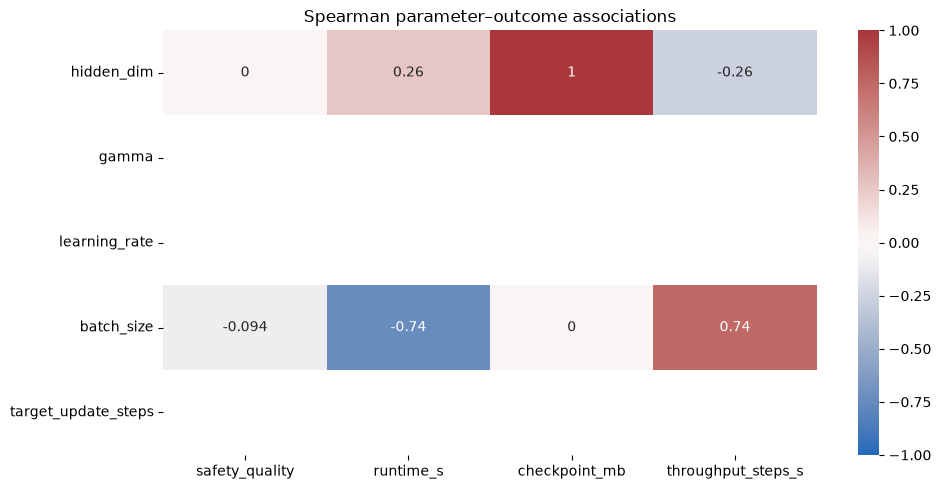

Most influential measured parameter: hidden_dim (max |rho|=1.00). Treat as association, not causal importance.


In [15]:
import seaborn as sns
from ips.experiment_analysis import parameter_effects
effects = parameter_effects(bench)
display(effects.round(3))
params = ['hidden_dim','gamma','learning_rate','batch_size','target_update_steps']
outs = ['safety_quality','runtime_s','checkpoint_mb','throughput_steps_s']
corr = bench[params+outs].corr(method='spearman').loc[params, outs]
plt.figure(figsize=(10,5)); sns.heatmap(corr, annot=True, center=0, cmap='vlag', vmin=-1, vmax=1)
plt.title('Spearman parameter–outcome associations'); plt.tight_layout(); plt.show()
top_effect = effects.iloc[0]
print(f"Most influential measured parameter: {top_effect.parameter} (max |rho|={top_effect.importance:.2f}). Treat as association, not causal importance.")

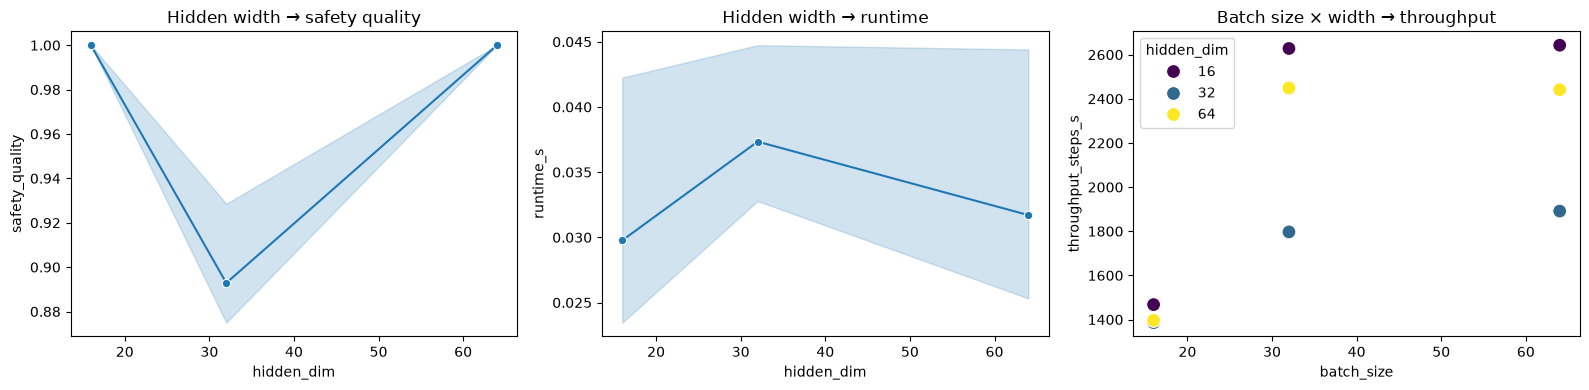

Expected: width generally increases parameter/checkpoint cost. Observed quality may be non-monotonic because additional capacity does not guarantee better policy learning.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.lineplot(data=bench, x='hidden_dim', y='safety_quality', marker='o', ax=axes[0]); axes[0].set_title('Hidden width → safety quality')
sns.lineplot(data=bench, x='hidden_dim', y='runtime_s', marker='o', ax=axes[1]); axes[1].set_title('Hidden width → runtime')
sns.scatterplot(data=bench, x='batch_size', y='throughput_steps_s', hue='hidden_dim', palette='viridis', s=100, ax=axes[2]); axes[2].set_title('Batch size × width → throughput')
plt.tight_layout(); plt.show()
print('Expected: width generally increases parameter/checkpoint cost. Observed quality may be non-monotonic because additional capacity does not guarantee better policy learning.')

## 14 — Parameter interactions

The grid supports a bounded width × batch-size interaction view. Blank combinations were not executed and must not be interpolated as measured evidence. A surprising reversal—where a larger batch helps one width but hurts another—is a reason to run a factorial follow-up.

batch_size,16,32,64
hidden_dim,,,
16,1.000,1.000,1.000
32,0.929,0.875,0.875
64,1.000,1.000,1.000


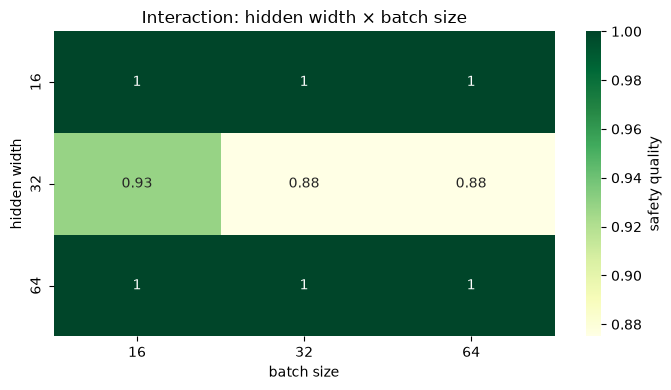

Observed 9/9 interaction cells. Next step should fill missing cells before strong interaction claims.


In [17]:
from ips.experiment_analysis import interaction_table
interaction = interaction_table(bench)
display(interaction.round(3))
plt.figure(figsize=(7,4)); sns.heatmap(interaction, annot=True, cmap='YlGn', cbar_kws={'label':'safety quality'})
plt.title('Interaction: hidden width × batch size'); plt.ylabel('hidden width'); plt.xlabel('batch size'); plt.tight_layout(); plt.show()
observed_cells = int(interaction.notna().sum().sum())
print(f'Observed {observed_cells}/{interaction.size} interaction cells. Next step should fill missing cells before strong interaction claims.')

## 15 — Automatic outlier detection and root-cause association

Robust median absolute deviation (MAD) is used because benchmark grids are small and runtime distributions can be skewed. Runs are never deleted automatically. For each flagged run, the notebook names the anomalous outcome and the most unusual tested parameter, explicitly labelling this as association rather than causation.

,name,outlier_score,runtime_s,peak_python_memory_mb,safety_quality,outlier_explanation
0,DQN-h16-b16,64.735,0.042,0.297,1.000,peak_python_memory_mb is robustly above median...
3,DQN-h32-b16,6.697,0.045,0.252,0.929,peak_python_memory_mb is robustly above median...
6,DQN-h64-b16,10.144,0.044,0.254,1.000,peak_python_memory_mb is robustly above median...


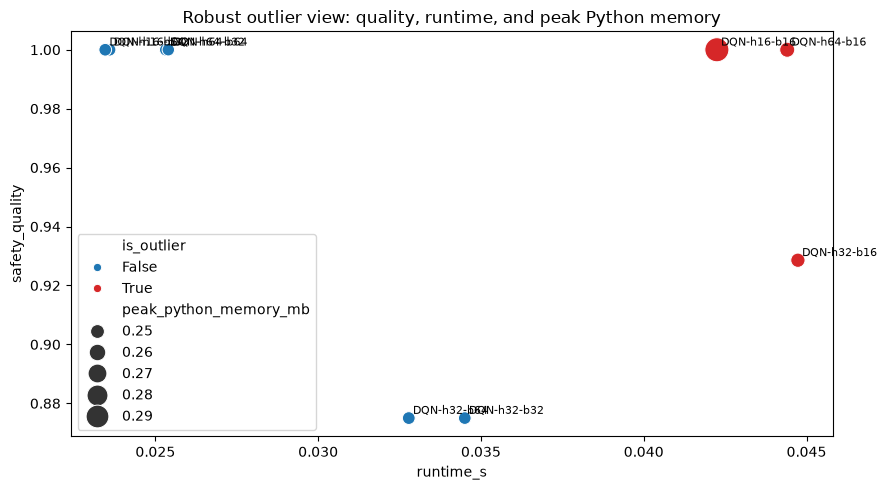

Detected outliers: 3 — retain and investigate them; do not silently remove them.


In [18]:
from ips.experiment_analysis import detect_outliers
diagnosed = detect_outliers(bench)
outliers = diagnosed[diagnosed.is_outlier]
display(outliers[['name','outlier_score','runtime_s','peak_python_memory_mb','safety_quality','outlier_explanation']].round(3))
plt.figure(figsize=(9,5)); sns.scatterplot(data=diagnosed, x='runtime_s', y='safety_quality', hue='is_outlier', size='peak_python_memory_mb', sizes=(80,300), palette={False:'tab:blue',True:'tab:red'})
for _, r in diagnosed.iterrows(): plt.annotate(r['name'], (r.runtime_s,r.safety_quality), fontsize=8, xytext=(3,3), textcoords='offset points')
plt.title('Robust outlier view: quality, runtime, and peak Python memory'); plt.tight_layout(); plt.show()
print('Detected outliers:', len(outliers), '— retain and investigate them; do not silently remove them.')

## 16 — Statistical reliability

The earlier dataset-backed DQN run supplies repeated final-test measurements. Mean, median, standard deviation, range, coefficient of variation, and a normal-approximation 95% confidence interval are shown. With only three quick-mode seeds, intervals are descriptive; heavy mode's five seeds is the minimum project standard.

,mean,median,std,min,max,cv,ci95_halfwidth
episodes,21.0000,21.0000,0.0000,21.0000,21.0000,0.0000,0.0000
attack_episodes,19.0000,19.0000,0.0000,19.0000,19.0000,0.0000,0.0000
containment_rate,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000
compromise_rate,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000
false_preventions_per_episode,0.1905,0.0000,0.3299,0.0000,0.5714,1.7321,0.3733
disruptive_actions_per_episode,1.3968,1.1905,0.3574,1.1905,1.8095,0.2559,0.4044
mean_return,6.2937,7.0000,1.3068,4.7857,7.0952,0.2076,1.4788
return_std,4.6538,2.3177,4.0624,2.2991,9.3447,0.8729,4.5971


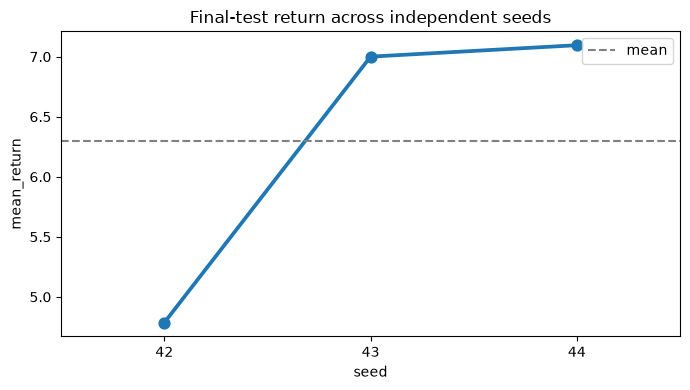

If confidence intervals overlap materially between finalists, report a tie and collect more seeds rather than naming a winner.


In [19]:
numeric = per_seed.select_dtypes('number').drop(columns='seed')
reliability = pd.DataFrame({'mean':numeric.mean(), 'median':numeric.median(), 'std':numeric.std(ddof=1), 'min':numeric.min(), 'max':numeric.max()})
reliability['cv'] = reliability['std'] / reliability['mean'].abs().replace(0,np.nan)
reliability['ci95_halfwidth'] = 1.96 * reliability['std'] / np.sqrt(len(per_seed))
display(reliability.round(4))
metric='mean_return'; plt.figure(figsize=(7,4)); sns.pointplot(data=per_seed, x='seed', y=metric, errorbar=None); plt.axhline(per_seed[metric].mean(), ls='--', color='gray', label='mean'); plt.title('Final-test return across independent seeds'); plt.legend(); plt.tight_layout(); plt.show()
print('If confidence intervals overlap materially between finalists, report a tie and collect more seeds rather than naming a winner.')

## 17 — Optimal configurations and dynamic recommendations

There is no universal best model. Quality, speed, memory, and overall winners are calculated independently. The overall score is transparent: 60% normalized safety quality, 25% speed, and 15% checkpoint memory. Change these weights if deployment priorities differ.

In [20]:
from ips.experiment_analysis import objective_winners, dynamic_recommendations
winners = objective_winners(bench)
display(winners[['objective','name','safety_quality','runtime_s','checkpoint_mb','overall_score','pareto_optimal']].round(4))
recommendations = dynamic_recommendations(bench)
for message in recommendations: print('•', message)

,objective,name,safety_quality,runtime_s,checkpoint_mb,overall_score,pareto_optimal
0,best_quality,DQN-h16-b16,1.0,0.0422,0.0052,0.7792,False
1,fastest,DQN-h16-b64,1.0,0.0235,0.0052,1.0000,True
2,lowest_checkpoint_memory,DQN-h16-b16,1.0,0.0422,0.0052,0.7792,False
3,best_overall_60Q_25S_15M,DQN-h16-b64,1.0,0.0235,0.0052,1.0000,True


• Best observed overall trade-off: DQN-h16-b64 (score=1.000).
• Quality priority: DQN-h16-b16 with safety_quality=1.000.
• Speed priority: DQN-h16-b64 at 0.023s.
• Strongest measured monotonic association: hidden_dim (max |Spearman rho|=1.00).
• Pareto candidates: DQN-h16-b64.
• Next experiment: add an intermediate/extended hidden-width point to resolve the quality-cost curve.
• Reliability gap: repeat Pareto finalists across at least five seeds before declaring a winner.
• Model-family gap: benchmark a contextual bandit and masked PPO only after the DQN reward-sensitivity check.


## 18 — Dynamic experiment dashboard

This compact dashboard is generated entirely from the current run. Rerunning with different candidates, data, or seeds updates every winner, outlier count, influential parameter, Pareto set, and next recommendation.

In [21]:
best_quality = winners.set_index('objective').loc['best_quality']
fastest = winners.set_index('objective').loc['fastest']
lowest_memory = winners.set_index('objective').loc['lowest_checkpoint_memory']
best_overall = winners.set_index('objective').loc['best_overall_60Q_25S_15M']
dashboard = pd.Series({'experiments_executed':len(bench), 'models_compared':bench.name.nunique(), 'configurations_tested':len(bench), 'best_quality':f"{best_quality['name']} ({best_quality['safety_quality']:.3f})", 'fastest':f"{fastest['name']} ({fastest['runtime_s']:.3f}s)", 'lowest_memory':f"{lowest_memory['name']} ({lowest_memory['checkpoint_mb']:.3f} MB)", 'best_overall':best_overall['name'], 'detected_outliers':len(outliers), 'most_influential_parameter':effects.iloc[0].parameter, 'interaction_coverage':f'{observed_cells}/{interaction.size}', 'pareto_candidates':', '.join(bench.loc[bench.pareto_optimal,'name']), 'recommended_next_experiment':recommendations[-1]}, name='Current dynamic result')
display(dashboard.to_frame())
dashboard.to_json(OUTPUT / 'experiment_dashboard.json', indent=2)

,Current dynamic result
experiments_executed,9
models_compared,9
configurations_tested,9
best_quality,DQN-h16-b16 (1.000)
fastest,DQN-h16-b64 (0.023s)
lowest_memory,DQN-h16-b16 (0.005 MB)
best_overall,DQN-h16-b64
detected_outliers,3
most_influential_parameter,hidden_dim
interaction_coverage,9/9


## 19 — Interim interpretation before advanced evidence tests

A strong result requires all of the following: group-disjoint episodes, out-of-fold detector scores, at least three RL seeds, validation-only checkpoint selection, one final-test evaluation per seed, and comparison against allow/rule/aggressive policies. If this notebook used the synthetic fixture, it proves software correctness only. The next evidence gate is creating `data/ips_events/events.parquet` from a timestamped dataset, followed by contained cyber-range intervention logs that can replace counterfactual outcomes.

In [22]:
final = {'evidence_kind': evidence_kind, 'tests_passed': tests.returncode == 0, 'simulator_dqn': trained.best_validation.to_dict(), 'dataset_multi_seed_mean': per_seed.drop(columns='seed').mean(numeric_only=True).to_dict(), 'dataset_multi_seed_std': per_seed.drop(columns='seed').std(ddof=0, numeric_only=True).to_dict()}
(OUTPUT / 'notebook_summary.json').write_text(json.dumps(final, indent=2, sort_keys=True)+'\n', encoding='utf-8')
display(pd.Series(final, name='current project conclusion'))
print('Saved:', OUTPUT / 'notebook_summary.json')

evidence_kind              SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE
tests_passed                                                            True
simulator_dqn              {'episodes': 50, 'attack_episodes': 20, 'benig...
dataset_multi_seed_mean    {'episodes': 21.0, 'attack_episodes': 19.0, 'c...
dataset_multi_seed_std     {'episodes': 0.0, 'attack_episodes': 0.0, 'con...
Name: current project conclusion, dtype: object

Saved: /Users/hexenmeister/Library/Mobile Documents/com~apple~CloudDocs/Desktop/don't delete update/codes/network-intrusion-detection-ml/results/notebook_ips_lab/notebook_summary.json


## 20 — Real timestamped dataset adapter

The adapter reads CSV/Parquet traffic, excludes configured identifiers and labels from detector features, creates campaign/time-window episodes, and generates group-safe out-of-fold HistGB probabilities plus benign-only Isolation Forest anomaly scores. It never guesses group columns because a wrong grouping would invalidate the experiment.

In [23]:
from ips.real_data_adapter import AdapterConfig, write_events
source_config_path = REPO / 'data' / 'ips_events' / 'source_config.json'
if source_config_path.exists():
    source_spec = json.loads(source_config_path.read_text())
    events = write_events(REPO/source_spec['source'], event_path, AdapterConfig(**source_spec['adapter']))
    episodes=build_episodes(events); splits=split_episodes_by_group(episodes,seed=SEED); assert_group_disjoint(splits)
    evidence_kind='REAL DATASET-BACKED OBSERVATIONS WITH GROUP-SAFE OOF SCORES'
    adapter_status={'status':'generated','source':source_spec['source'],'events':len(events),'episodes':len(episodes),'groups':events.group_id.nunique()}
else:
    adapter_status={'status':'blocked_missing_source_config','required':'data/ips_events/source_config.json','output':'data/ips_events/events.parquet','safeguard':'No raw schema/group IDs guessed'}
display(pd.Series(adapter_status,name='real-data adapter status').to_frame())
print('CLI example: python -m ips.real_data_adapter SOURCE.csv --timestamp-col Timestamp --label-col Label --group-cols "Source IP,Destination IP"')
print('Current evidence:',evidence_kind)

,real-data adapter status
status,blocked_missing_source_config
required,data/ips_events/source_config.json
output,data/ips_events/events.parquet
safeguard,No raw schema/group IDs guessed


CLI example: python -m ips.real_data_adapter SOURCE.csv --timestamp-col Timestamp --label-col Label --group-cols "Source IP,Destination IP"
Current evidence: SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE


## 21 — Family containment, action behavior, reward sensitivity, and detector stress

This loads the best validation-selected DQN, reports containment by family, shows every executed action, sweeps the four central reward terms, and corrupts detector telemetry without changing ground truth. These views expose rare-family failure, over-blocking, reward fragility, and unsafe behavior under uncertainty.

,selected DQN
episodes,21.000000
attack_episodes,19.000000
containment_rate,1.000000
compromise_rate,0.000000
false_preventions_per_episode,0.000000
mean_return,7.023810
return_std,2.301533


,attack_family,episodes,contained,compromised,containment_rate,compromise_rate
0,BruteForce,4,4,0,1.0,0.0
1,DoS,1,1,0,1.0,0.0
2,Exploitation,3,3,0,1.0,0.0
3,Probe,5,5,0,1.0,0.0
4,R2L,4,4,0,1.0,0.0
5,U2R,2,2,0,1.0,0.0


,action,count,fraction
0,ALLOW,14,0.35
1,MONITOR,0,0.00
2,RATE_LIMIT,0,0.00
3,DROP_FLOW,0,0.00
4,TEMP_BLOCK_SOURCE,26,0.65
5,BLOCK_DESTINATION_PORT,0,0.00
6,ISOLATE_HOST,0,0.00


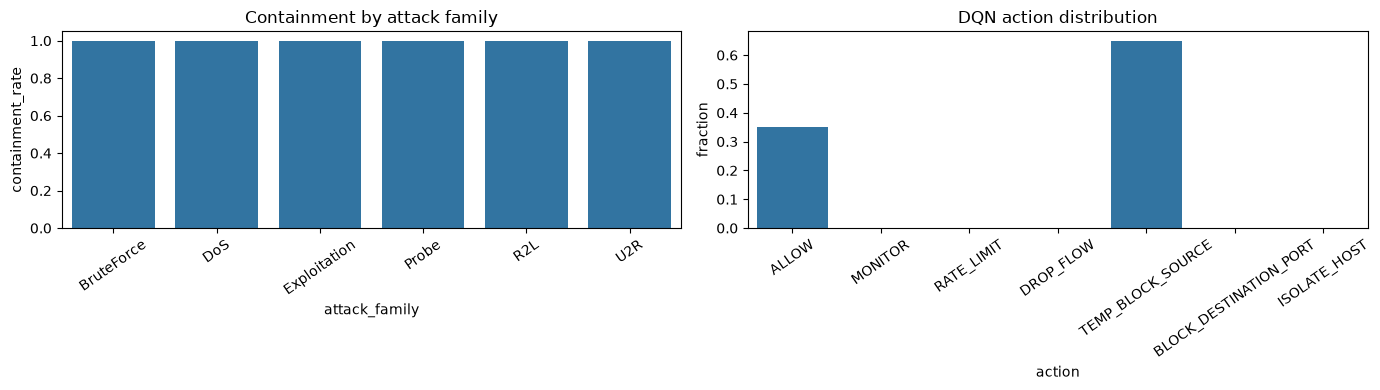

Missing target families: none


,parameter,value,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,contained_attack,4.0,21.0,19.0,1.0,0.0,0.0,3.4048,1.1508
1,contained_attack,8.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
2,contained_attack,12.0,21.0,19.0,1.0,0.0,0.0,10.6429,3.4680
3,successful_compromise,-15.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
4,successful_compromise,-25.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
5,successful_compromise,-40.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
6,false_prevention,-2.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
7,false_prevention,-4.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
8,false_prevention,-8.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
9,critical_service_disruption,-6.0,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015


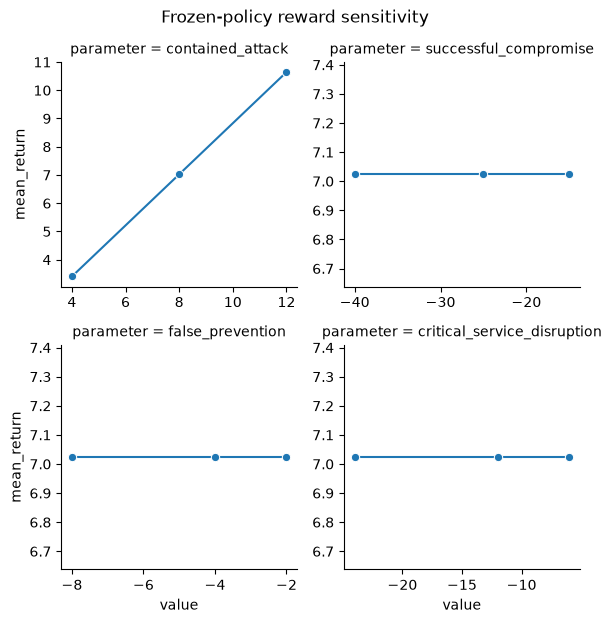

,scenario,score_noise,false_positive_shift,telemetry_dropout,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,clean,0.00,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0952,2.3177
1,score_noise_0.10,0.10,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0000,2.2939
2,score_noise_0.25,0.25,0.0,0.00,21.0,19.0,0.9474,0.0526,0.0952,4.8333,8.0005
3,benign_shift_0.20,0.00,0.2,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0952,2.3177
4,telemetry_dropout_25pct,0.00,0.0,0.25,21.0,19.0,1.0000,0.0000,0.0000,6.8333,2.2800
5,combined_stress,0.15,0.2,0.25,21.0,19.0,1.0000,0.0000,0.0952,6.3571,3.4057


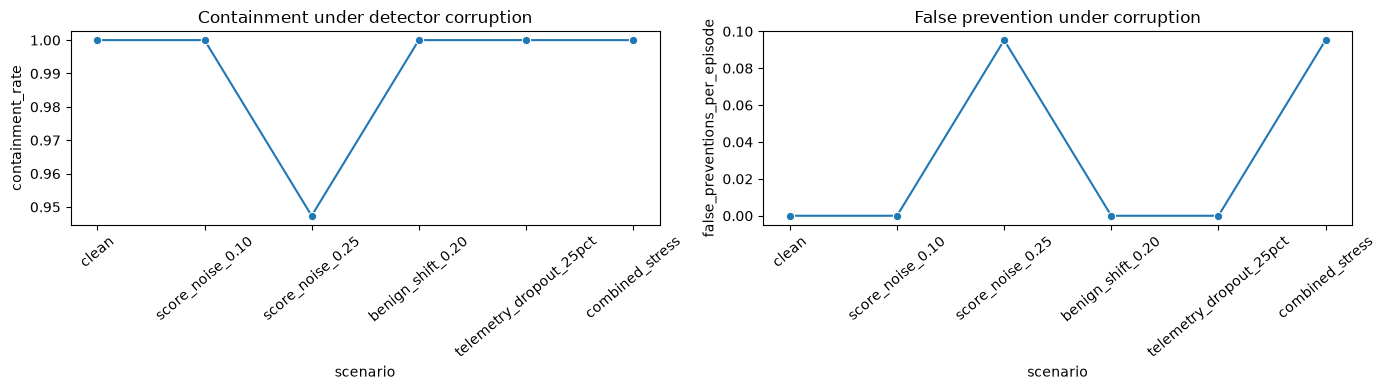

In [24]:
import torch
from ips.dqn import QNetwork
from ips.evidence_analysis import network_policy,evaluate_detailed,reward_sensitivity,adversarial_noise_sweep
selected_row=bench.loc[bench.overall_score.idxmax()]
selected_network=QNetwork(7,7,int(selected_row.hidden_dim))
selected_network.load_state_dict(torch.load(OUTPUT/'candidate_benchmark'/selected_row['name']/'best.pt',map_location='cpu')['model_state_dict']); selected_network.eval()
selected_policy=network_policy(selected_network,SEED)
family_metrics,action_metrics,detailed_summary=evaluate_detailed(selected_policy,splits.test,seed=SEED+2_000_000)
display(pd.Series(detailed_summary,name='selected DQN').to_frame()); display(family_metrics.round(4)); display(action_metrics.round(4))
fig,axes=plt.subplots(1,2,figsize=(14,4))
if not family_metrics.empty: sns.barplot(data=family_metrics,x='attack_family',y='containment_rate',ax=axes[0]); axes[0].tick_params(axis='x',rotation=35)
sns.barplot(data=action_metrics,x='action',y='fraction',ax=axes[1]); axes[1].tick_params(axis='x',rotation=35); axes[0].set_title('Containment by attack family'); axes[1].set_title('DQN action distribution'); plt.tight_layout(); plt.show()
target_families={'DoS','Probe','BruteForce','Exploitation','R2L','U2R'}; missing_families=sorted(target_families-set(family_metrics.attack_family if not family_metrics.empty else [])); print('Missing target families:',missing_families or 'none')
reward_grid=reward_sensitivity(selected_policy,splits.test,seed=SEED+2_000_000); display(reward_grid.round(4))
g=sns.relplot(data=reward_grid,x='value',y='mean_return',col='parameter',col_wrap=2,kind='line',marker='o',facet_kws={'sharex':False,'sharey':False},height=3); g.fig.suptitle('Frozen-policy reward sensitivity',y=1.03); plt.show()
return_ranges=reward_grid.groupby('parameter').mean_return.agg(lambda s:s.max()-s.min()).sort_values(ascending=False)
dqn_robustness=adversarial_noise_sweep(selected_policy,splits.test,seed=SEED); display(dqn_robustness.round(4))
fig,axes=plt.subplots(1,2,figsize=(14,4)); sns.lineplot(data=dqn_robustness,x='scenario',y='containment_rate',marker='o',ax=axes[0]); sns.lineplot(data=dqn_robustness,x='scenario',y='false_preventions_per_episode',marker='o',ax=axes[1]); [ax.tick_params(axis='x',rotation=40) for ax in axes]; axes[0].set_title('Containment under detector corruption'); axes[1].set_title('False prevention under corruption'); plt.tight_layout(); plt.show()

## 22 — Complete 3×3 grid and five-seed finalists

Candidate discovery is validation-only. The full width × batch grid covers all nine interactions. The two strongest validation candidates are then retrained across five seeds; each selected checkpoint evaluates final test once.

Factorial coverage: 9 configurations; 9 / 9 interaction cells


,name,safety_quality_mean,safety_quality_std,containment_mean,compromise_mean,return_mean,return_std_between,safety_ci95_halfwidth
0,DQN-h16-b32,0.7570,0.5116,0.8842,0.1158,2.2348,8.1219,0.4485
1,DQN-h16-b64,0.7359,0.5027,0.8737,0.1263,1.8110,8.0148,0.4406


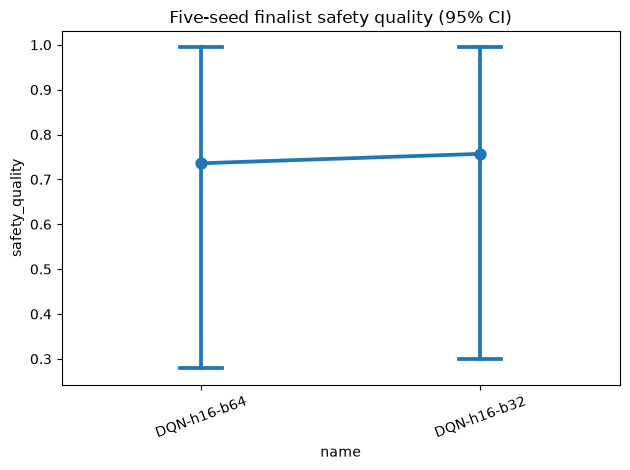

In [25]:
from ips.experiment_analysis import Candidate,benchmark_finalists_multi_seed
print('Factorial coverage:',len(bench),'configurations;',int(interaction.notna().sum().sum()),'/',interaction.size,'interaction cells')
finalist_rows=bench.sort_values(['safety_quality','runtime_s'],ascending=[False,True]).head(2)
finalists=tuple(Candidate(str(r['name']),int(r.hidden_dim),float(r.gamma),float(r.learning_rate),int(r.batch_size),int(r.target_update_steps),100 if RUN_HEAVY else 30) for _,r in finalist_rows.iterrows())
finalist_runs=benchmark_finalists_multi_seed(splits,finalists,seeds=(42,43,44,45,46),output_dir=OUTPUT/'finalists_five_seed')
finalist_summary=finalist_runs.groupby('name').agg(safety_quality_mean=('safety_quality','mean'),safety_quality_std=('safety_quality','std'),containment_mean=('containment_rate','mean'),compromise_mean=('compromise_rate','mean'),return_mean=('mean_return','mean'),return_std_between=('mean_return','std')).reset_index()
finalist_summary['safety_ci95_halfwidth']=1.96*finalist_summary.safety_quality_std/np.sqrt(5); display(finalist_summary.round(4))
sns.pointplot(data=finalist_runs,x='name',y='safety_quality',errorbar=('ci',95),capsize=.15); plt.title('Five-seed finalist safety quality (95% CI)'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 23 — Contextual bandit, masked PPO, and constrained PPO

The bandit tests whether delayed credit is necessary. PPO learns a stochastic masked policy without replay. Constrained PPO learns a multiplier when disruptive actions exceed its budget. All are trained and evaluated using the same episodes and action accounting.

,policy,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,DQN,21.0,19.0,1.0,0.0,0.0,7.0238,2.3015
1,LinUCB_bandit,21.0,19.0,1.0,0.0,0.0,7.0452,2.3080
2,Masked_PPO,21.0,19.0,1.0,0.0,0.0,6.8952,2.8390
3,Constrained_PPO,21.0,19.0,1.0,0.0,0.0,6.8952,2.8390


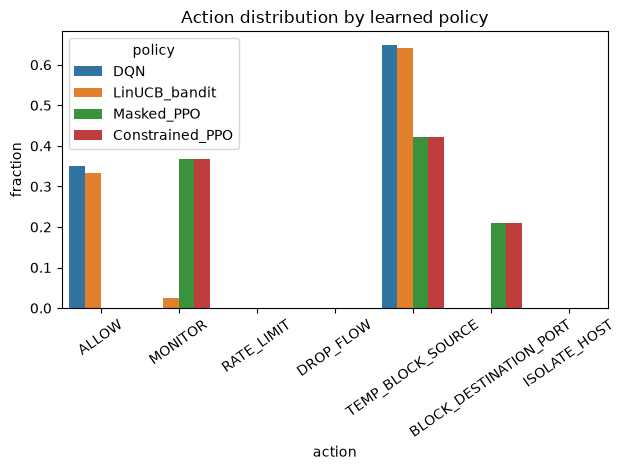

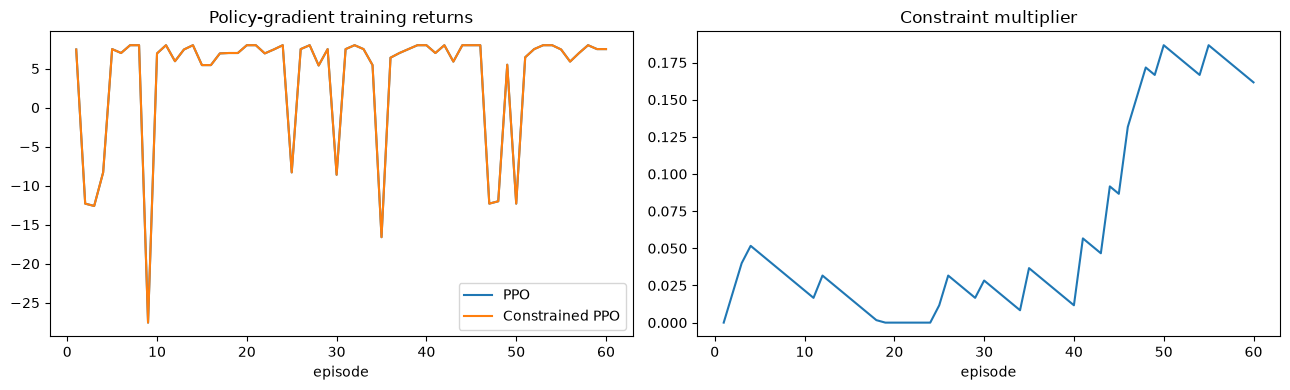

In [26]:
from ips.advanced_policies import train_bandit,train_ppo,PpoConfig,actor_policy
bandit=train_bandit(splits.train,training_episodes=300 if RUN_HEAVY else 60,seed=SEED); bandit_policy=lambda state,mask:bandit.choose(state,mask)
ppo_model,ppo_history=train_ppo(splits.train,config=PpoConfig(training_episodes=300 if RUN_HEAVY else 60),seed=SEED)
cppo_model,cppo_history=train_ppo(splits.train,config=PpoConfig(training_episodes=300 if RUN_HEAVY else 60,constrained=True,disruption_limit=.10),seed=SEED)
policies={'DQN':selected_policy,'LinUCB_bandit':bandit_policy,'Masked_PPO':actor_policy(ppo_model),'Constrained_PPO':actor_policy(cppo_model)}
policy_rows=[]; policy_actions=[]
for name,policy in policies.items():
    _,at,sm=evaluate_detailed(policy,splits.test,seed=SEED+2_000_000); policy_rows.append({'policy':name,**sm}); policy_actions.append(at.assign(policy=name))
policy_comparison=pd.DataFrame(policy_rows); all_policy_actions=pd.concat(policy_actions,ignore_index=True); display(policy_comparison.round(4))
sns.barplot(data=all_policy_actions,x='action',y='fraction',hue='policy'); plt.title('Action distribution by learned policy'); plt.xticks(rotation=35); plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,4)); ppo_history.plot(x='episode',y='return',ax=axes[0],label='PPO'); cppo_history.plot(x='episode',y='return',ax=axes[0],label='Constrained PPO'); cppo_history.plot(x='episode',y='lagrange',ax=axes[1],title='Constraint multiplier',legend=False); axes[0].set_title('Policy-gradient training returns'); plt.tight_layout(); plt.show()

## 24 — Native resources and cross-policy adversarial robustness

Resource profiling adds decision-latency percentiles, throughput, process CPU, one-core utilization, and maximum RSS. The same policies are then tested under score noise, benign-score shifts, telemetry dropout, and combined stress.

,policy,decisions,latency_mean_ms,latency_p50_ms,latency_p95_ms,latency_p99_ms,throughput_decisions_s,process_cpu_s,cpu_utilization_one_core_pct,max_rss_mb
0,DQN,210.0,0.0237,0.0208,0.0265,0.0332,41832.3277,0.0051,101.0749,560.9844
1,LinUCB_bandit,210.0,0.0228,0.0221,0.0273,0.0307,43577.8765,0.0048,100.0216,560.9844
2,Masked_PPO,210.0,0.0141,0.0129,0.0183,0.0276,70193.0308,0.0030,99.7410,560.9844
3,Constrained_PPO,210.0,0.0136,0.0128,0.0184,0.0191,72419.0123,0.0029,100.0417,560.9844


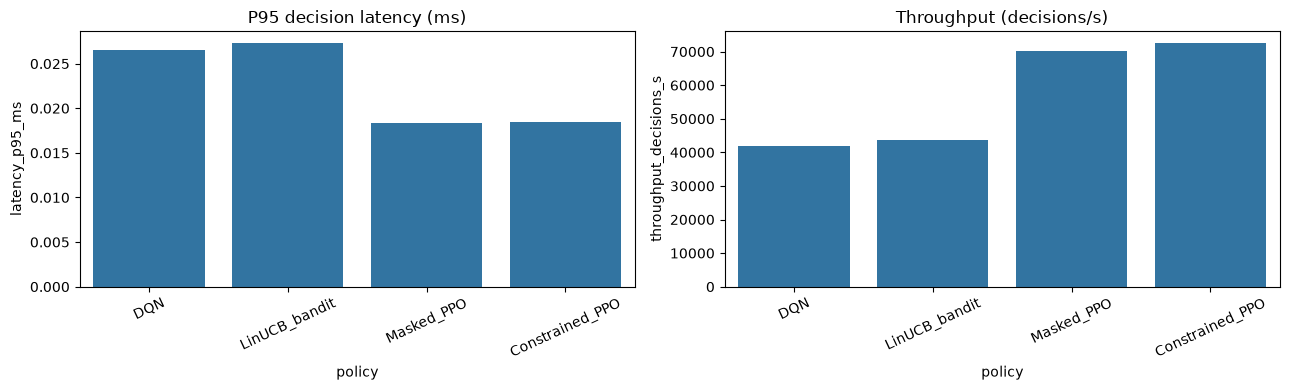

,scenario,score_noise,false_positive_shift,telemetry_dropout,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std,policy
0,clean,0.00,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0952,2.3177,DQN
1,score_noise_0.10,0.10,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0000,2.2939,DQN
2,score_noise_0.25,0.25,0.0,0.00,21.0,19.0,0.9474,0.0526,0.0952,4.8333,8.0005,DQN
3,benign_shift_0.20,0.00,0.2,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0952,2.3177,DQN
4,telemetry_dropout_25pct,0.00,0.0,0.25,21.0,19.0,1.0000,0.0000,0.0000,6.8333,2.2800,DQN
5,combined_stress,0.15,0.2,0.25,21.0,19.0,1.0000,0.0000,0.0952,6.3571,3.4057,DQN
6,clean,0.00,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0929,2.3173,LinUCB_bandit
7,score_noise_0.10,0.10,0.0,0.00,21.0,19.0,1.0000,0.0000,0.0000,6.9857,2.2925,LinUCB_bandit
8,score_noise_0.25,0.25,0.0,0.00,21.0,19.0,0.9474,0.0526,0.0952,4.8048,8.0235,LinUCB_bandit
9,benign_shift_0.20,0.00,0.2,0.00,21.0,19.0,1.0000,0.0000,0.0000,7.0929,2.3173,LinUCB_bandit


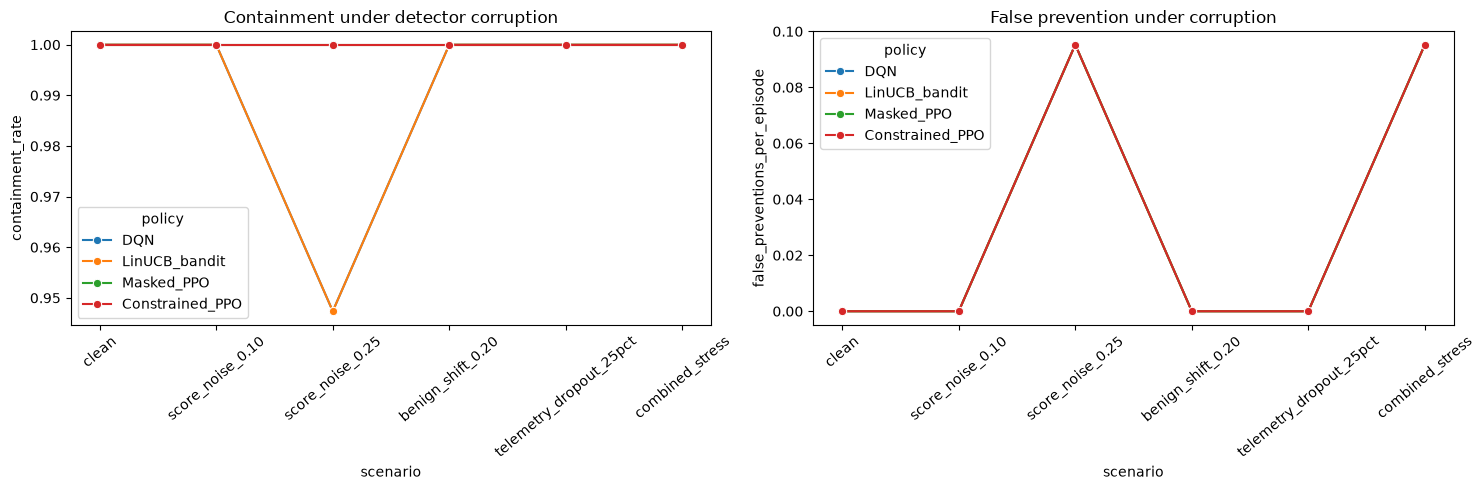

,containment_degradation
policy,
DQN,0.0
LinUCB_bandit,0.0
Masked_PPO,0.0
Constrained_PPO,0.0


In [27]:
from ips.evidence_analysis import profile_policy
from ips.dataset_environment import DatasetBackedIpsEnv
profile_states=[];profile_masks=[]
for ep in splits.test:
    envp=DatasetBackedIpsEnv(ep,seed=SEED);ob,inf=envp.reset(seed=SEED);profile_states.append(ob.as_array());profile_masks.append(inf['action_mask'])
resource_rows=[{'policy':name,**profile_policy(policy,np.stack(profile_states),np.stack(profile_masks),repeats=50 if RUN_HEAVY else 10)} for name,policy in policies.items()]
resource_profile=pd.DataFrame(resource_rows);display(resource_profile.round(4))
fig,axes=plt.subplots(1,2,figsize=(13,4));sns.barplot(data=resource_profile,x='policy',y='latency_p95_ms',ax=axes[0]);sns.barplot(data=resource_profile,x='policy',y='throughput_decisions_s',ax=axes[1]);[ax.tick_params(axis='x',rotation=25) for ax in axes];axes[0].set_title('P95 decision latency (ms)');axes[1].set_title('Throughput (decisions/s)');plt.tight_layout();plt.show()
robustness=pd.concat([adversarial_noise_sweep(policy,splits.test,seed=SEED).assign(policy=name) for name,policy in policies.items()],ignore_index=True);display(robustness.round(4))
fig,axes=plt.subplots(1,2,figsize=(15,5));sns.lineplot(data=robustness,x='scenario',y='containment_rate',hue='policy',marker='o',ax=axes[0]);sns.lineplot(data=robustness,x='scenario',y='false_preventions_per_episode',hue='policy',marker='o',ax=axes[1]);[ax.tick_params(axis='x',rotation=40) for ax in axes];axes[0].set_title('Containment under detector corruption');axes[1].set_title('False prevention under corruption');plt.tight_layout();plt.show()
clean=robustness[robustness.scenario=='clean'].set_index('policy');stress=robustness[robustness.scenario=='combined_stress'].set_index('policy');degradation=(clean.containment_rate-stress.containment_rate).sort_values();display(degradation.to_frame('containment_degradation'))

## 25 — Enhanced evidence dashboard and final recommendations

The final dashboard joins data provenance, family coverage, action behavior, reward sensitivity, five-seed finalists, policy-family comparisons, native resources, and adversarial robustness. It updates automatically whenever real events or configurations change.

In [28]:
enhanced_dashboard=pd.Series({'evidence_kind':evidence_kind,'real_adapter_status':adapter_status['status'],'factorial_configs':len(bench),'interaction_coverage':f'{int(interaction.notna().sum().sum())}/{interaction.size}','five_seed_finalists':', '.join(finalist_summary.name),'five_seed_best':finalist_summary.loc[finalist_summary.safety_quality_mean.idxmax(),'name'],'best_policy_return':policy_comparison.loc[policy_comparison.mean_return.idxmax(),'policy'],'tested_families':', '.join(family_metrics.attack_family) if not family_metrics.empty else 'none','missing_target_families':', '.join(missing_families) if missing_families else 'none','most_common_dqn_action':action_metrics.loc[action_metrics['count'].idxmax(),'action'],'most_reward_sensitive_term':return_ranges.index[0],'lowest_p95_latency_policy':resource_profile.loc[resource_profile.latency_p95_ms.idxmin(),'policy'],'most_robust_policy':degradation.index[0],'test_episodes':len(splits.test),'test_attack_episodes':sum(ep.contains_attack for ep in splits.test)},name='Enhanced current evidence')
display(enhanced_dashboard.to_frame());enhanced_dashboard.to_json(OUTPUT/'enhanced_experiment_dashboard.json',indent=2)
print('Final recommendation: treat all policy rankings as simulator evidence until the real adapter status is generated and each target attack family has sufficient held-out episodes.')

,Enhanced current evidence
evidence_kind,SYNTHETIC CONTRACT FIXTURE — NOT DATASET EVIDENCE
real_adapter_status,blocked_missing_source_config
factorial_configs,9
interaction_coverage,9/9
five_seed_finalists,"DQN-h16-b32, DQN-h16-b64"
five_seed_best,DQN-h16-b32
best_policy_return,LinUCB_bandit
tested_families,"BruteForce, DoS, Exploitation, Probe, R2L, U2R"
missing_target_families,none
most_common_dqn_action,TEMP_BLOCK_SOURCE


Final recommendation: treat all policy rankings as simulator evidence until the real adapter status is generated and each target attack family has sufficient held-out episodes.


## 26 — Real NSL-KDD evidence: calibration, uncertainty, and drift

This section uses the verified official NSL-KDD train/test files, not the synthetic fixture. Training detector probabilities are out-of-fold and official-test probabilities come from a train-only model. NSL-KDD has no trustworthy timestamps, hosts, campaigns, or observed prevention outcomes, so fixed-size family-pure sequences are explicitly **ordered-row proxies** and IPS outcomes remain counterfactual. Calibration is fitted on validation episodes only.

,real-data evidence contract
dataset,NSL-KDD
evidence_kind,real labelled flows; counterfactual IPS outcomes
train_rows,12000
official_test_rows,5000
sequence_semantics,ordered-row proxy; NSL-KDD has no timestamps
detector_train_scoring,out-of-fold
detector_test_scoring,fit on train only
group_semantics,family-pure fixed-size chunks; not hosts or ca...


,wall_time_s,cpu_time_s,cpu_utilization_one_core_pct,max_rss_mb,train_rows_per_s
0,1.826,1.8229,99.8285,837.0,6571.7708


,method,brier_score,ece_10_bins,mean_probability
0,raw,0.21224,0.22267,0.39292
2,isotonic,0.21294,0.22517,0.39220
1,platt,0.21800,0.21284,0.39547


,comparison,score_PSI,interpretation
0,OOF train → official test,0.18184,moderate drift


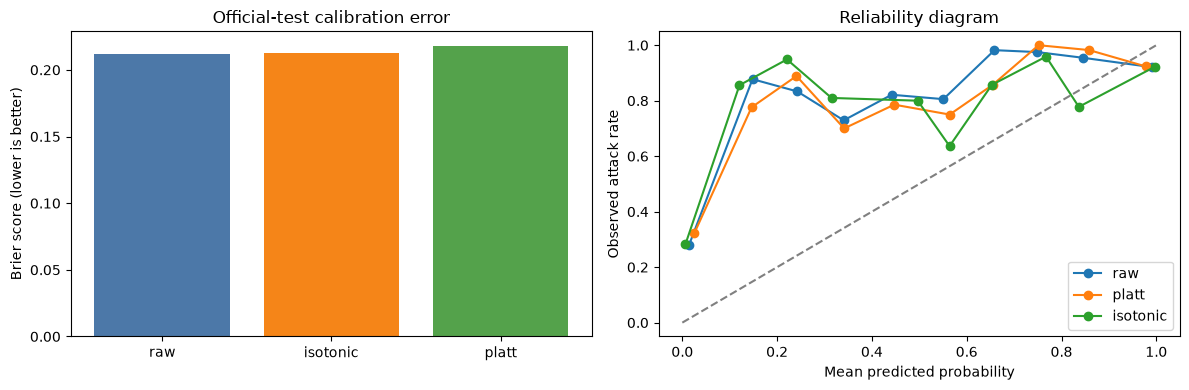

In [29]:
from sklearn.metrics import brier_score_loss
from data import load_nsl_kdd
from ips.nsl_adapter import NslIpsConfig, build_nsl_ips_evidence
from ips.real_policy_analysis import expected_calibration_error, fit_probability_calibrator, population_stability_index, escalation_decision
nsl_config = NslIpsConfig(max_train_rows=None if RUN_HEAVY else 12_000, max_test_rows=None if RUN_HEAVY else 5_000, episode_size=12, folds=5 if RUN_HEAVY else 3, seed=SEED)
nsl_evidence = build_nsl_ips_evidence(load_nsl_kdd('train'), load_nsl_kdd('test'), nsl_config)
def episode_arrays(episodes):
    events=[event for episode in episodes for event in episode.events]
    return np.array([event.threat_probability for event in events]), np.array([event.attack_present for event in events],dtype=int)
validation_scores, validation_labels = episode_arrays(nsl_evidence.splits.validation)
test_scores, test_labels = episode_arrays(nsl_evidence.splits.test)
train_scores, _ = episode_arrays(nsl_evidence.splits.train)
platt = fit_probability_calibrator(validation_scores, validation_labels, method='platt')
isotonic = fit_probability_calibrator(validation_scores, validation_labels, method='isotonic')
calibration_rows=[]
for method, scores in {'raw':test_scores, 'platt':platt(test_scores), 'isotonic':isotonic(test_scores)}.items():
    calibration_rows.append({'method':method, 'brier_score':brier_score_loss(test_labels,scores), 'ece_10_bins':expected_calibration_error(test_labels,scores,10), 'mean_probability':scores.mean()})
calibration_comparison=pd.DataFrame(calibration_rows).sort_values('brier_score')
drift_summary=pd.DataFrame([{'comparison':'OOF train → official test','score_PSI':population_stability_index(train_scores,test_scores),'interpretation':'material drift' if population_stability_index(train_scores,test_scores)>=0.25 else 'moderate drift' if population_stability_index(train_scores,test_scores)>=0.10 else 'low drift'}])
display(pd.Series(nsl_evidence.metadata,name='real-data evidence contract').to_frame())
display(pd.DataFrame([nsl_evidence.resources]).round(4)); display(calibration_comparison.round(5)); display(drift_summary.round(5))
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar(calibration_comparison.method,calibration_comparison.brier_score,color=['#4c78a8','#f58518','#54a24b']); axes[0].set(title='Official-test calibration error',ylabel='Brier score (lower is better)')
for method,scores in {'raw':test_scores,'platt':platt(test_scores),'isotonic':isotonic(test_scores)}.items():
    bins=pd.cut(scores,np.linspace(0,1,11),include_lowest=True); reliability=pd.DataFrame({'score':scores,'label':test_labels}).groupby(bins,observed=True).mean(); axes[1].plot(reliability.score,reliability.label,marker='o',label=method)
axes[1].plot([0,1],[0,1],'--',color='gray'); axes[1].set(title='Reliability diagram',xlabel='Mean predicted probability',ylabel='Observed attack rate'); axes[1].legend(); plt.tight_layout(); plt.show()

## 27 — Real-flow policy experiment: sequential consequences, escalation, and unseen families

DQN, LinUCB, masked PPO, and constrained PPO now train on real NSL-KDD detector observations. The environment retains sequential attack progression and action-dependent termination, while every outcome is labelled counterfactual. A virtual `ESCALATE` shadow decision measures analyst workload without bypassing the seven-action safety layer. Leave-one-family-out DQN runs test whether policy behavior transfers to attack families excluded during training.

In [30]:
import resource, time, torch
from ips.dataset import EpisodeSplits
from ips.dataset_experiment import DatasetTrainConfig, train_one_seed
from ips.dqn import DqnConfig, QNetwork
from ips.advanced_policies import train_bandit, train_ppo, actor_policy, PpoConfig
from ips.evidence_analysis import network_policy, evaluate_detailed
real_training_resources=[]
dqn_cfg=DqnConfig(hidden_dim=64,batch_size=32,replay_capacity=5000,warmup_steps=64,target_update_steps=100,epsilon_decay_steps=1500)
started=time.perf_counter(); cpu=time.process_time(); real_dqn_run=train_one_seed(nsl_evidence.splits,seed=SEED,dqn=dqn_cfg,training=DatasetTrainConfig(episodes=400 if RUN_HEAVY else 120,validation_interval=50 if RUN_HEAVY else 30),output_dir=OUTPUT/'real_nsl_dqn'); real_training_resources.append({'policy':'DQN','training_wall_s':time.perf_counter()-started,'training_cpu_s':time.process_time()-cpu})
real_dqn=QNetwork(7,7,64); real_dqn.load_state_dict(torch.load(real_dqn_run['checkpoint'],map_location='cpu')['model_state_dict'])
started=time.perf_counter(); cpu=time.process_time(); real_bandit=train_bandit(nsl_evidence.splits.train,training_episodes=400 if RUN_HEAVY else 120,seed=SEED); real_training_resources.append({'policy':'LinUCB','training_wall_s':time.perf_counter()-started,'training_cpu_s':time.process_time()-cpu})
started=time.perf_counter(); cpu=time.process_time(); real_ppo,real_ppo_history=train_ppo(nsl_evidence.splits.train,config=PpoConfig(training_episodes=250 if RUN_HEAVY else 70,hidden_dim=64),seed=SEED); real_training_resources.append({'policy':'Masked PPO','training_wall_s':time.perf_counter()-started,'training_cpu_s':time.process_time()-cpu})
started=time.perf_counter(); cpu=time.process_time(); real_cppo,real_cppo_history=train_ppo(nsl_evidence.splits.train,config=PpoConfig(training_episodes=250 if RUN_HEAVY else 70,hidden_dim=64,constrained=True,disruption_limit=0.10),seed=SEED); real_training_resources.append({'policy':'Constrained PPO','training_wall_s':time.perf_counter()-started,'training_cpu_s':time.process_time()-cpu})
real_policies={'DQN':network_policy(real_dqn,SEED),'LinUCB':real_bandit.choose,'Masked PPO':actor_policy(real_ppo),'Constrained PPO':actor_policy(real_cppo)}
real_policy_rows=[]; real_family_rows=[]; real_action_rows=[]
for policy_name,policy in real_policies.items():
    family,actions,summary=evaluate_detailed(policy,nsl_evidence.splits.test,seed=SEED); real_policy_rows.append({'policy':policy_name,**summary}); real_family_rows.append(family.assign(policy=policy_name)); real_action_rows.append(actions.assign(policy=policy_name))
real_policy_comparison=pd.DataFrame(real_policy_rows); real_family_comparison=pd.concat(real_family_rows,ignore_index=True); real_action_comparison=pd.concat(real_action_rows,ignore_index=True)
review=np.array([escalation_decision(score) for score in test_scores]); escalation_summary=pd.DataFrame([{'automation_rate':1-review.mean(),'human_review_rate':review.mean(),'attack_review_rate':review[test_labels==1].mean(),'benign_review_rate':review[test_labels==0].mean(),'reviewed_events':int(review.sum())}])
holdout_rows=[]
for family_name in ('DoS','Probe','R2L','U2R'):
    train_eps=tuple(ep for ep in nsl_evidence.splits.train if not any(ev.attack_family==family_name for ev in ep.events)); val_eps=tuple(ep for ep in nsl_evidence.splits.validation if not any(ev.attack_family==family_name for ev in ep.events)); test_eps=tuple(ep for ep in nsl_evidence.splits.test if any(ev.attack_family==family_name for ev in ep.events))
    if not min(len(train_eps),len(val_eps),len(test_eps)): continue
    started=time.perf_counter(); run=train_one_seed(EpisodeSplits(train_eps,val_eps,test_eps),seed=SEED,dqn=dqn_cfg,training=DatasetTrainConfig(episodes=100 if RUN_HEAVY else 35,validation_interval=25 if RUN_HEAVY else 15),output_dir=OUTPUT/'real_family_holdout'/family_name); holdout_rows.append({'excluded_family':family_name,'training_wall_s':time.perf_counter()-started,**run['final_test']})
unseen_family_results=pd.DataFrame(holdout_rows)
display(real_policy_comparison.round(4)); display(real_family_comparison.round(4)); display(real_action_comparison.pivot(index='policy',columns='action',values='fraction').fillna(0).round(4)); display(escalation_summary.round(4)); display(unseen_family_results.round(4))

,policy,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std
0,DQN,419.0,239.0,0.9331,0.0669,0.3294,1.6557,7.9384
1,LinUCB,419.0,239.0,0.8954,0.1046,0.0048,2.3325,7.9815
2,Masked PPO,419.0,239.0,0.7782,0.2218,0.3246,-1.5259,11.2908
3,Constrained PPO,419.0,239.0,0.7782,0.2218,0.3246,-1.5160,11.2814


,attack_family,episodes,contained,compromised,containment_rate,compromise_rate,policy
0,DoS,138,134,4,0.9710,0.0290,DQN
1,Probe,45,45,0,1.0000,0.0000,DQN
2,R2L,54,43,11,0.7963,0.2037,DQN
3,U2R,2,1,1,0.5000,0.5000,DQN
4,DoS,138,129,9,0.9348,0.0652,LinUCB
5,Probe,45,42,3,0.9333,0.0667,LinUCB
6,R2L,54,42,12,0.7778,0.2222,LinUCB
7,U2R,2,1,1,0.5000,0.5000,LinUCB
8,DoS,138,128,10,0.9275,0.0725,Masked PPO
9,Probe,45,42,3,0.9333,0.0667,Masked PPO


action,ALLOW,BLOCK_DESTINATION_PORT,DROP_FLOW,ISOLATE_HOST,MONITOR,RATE_LIMIT,TEMP_BLOCK_SOURCE
policy,,,,,,,
Constrained PPO,0.7467,0.1261,0.0000,0.0000,0.1272,0.0000,0.0000
DQN,0.7656,0.0517,0.0000,0.0232,0.0475,0.0498,0.0623
LinUCB,0.8318,0.0000,0.0398,0.0000,0.0363,0.0015,0.0905
Masked PPO,0.7310,0.1261,0.0000,0.0000,0.1429,0.0000,0.0000


,automation_rate,human_review_rate,attack_review_rate,benign_review_rate,reviewed_events
0,0.9664,0.0336,0.0499,0.0121,168


,excluded_family,training_wall_s,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,mean_return,return_std
0,DoS,0.2252,138,138,0.9203,0.0797,0.0,1.2464,5.1014,9.0173
1,Probe,0.1986,45,45,1.0000,0.0000,0.0,1.1778,7.8556,0.2713
2,R2L,0.1973,54,54,0.0370,0.9630,0.0,0.0926,-26.5833,6.8663
3,U2R,0.1969,2,2,0.5000,0.5000,0.0,1.0000,-9.5000,16.5000


## 28 — Professional real-data comparison, constraints, and resource consumption

This final dashboard combines security outcomes, action aggressiveness, analyst workload, hard operational constraints, training cost, process RSS, model size, throughput, and p50/p95/p99 inference latency. It separates detector evidence (real labels and official split) from prevention evidence (still counterfactual), and makes the LinUCB-versus-RL question explicit.

,policy,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,mean_return,return_std,aggressiveness_score,latency_p95_ms,throughput_decisions_s,model_mb,max_rss_mb,false_prevention_constraint,latency_constraint,constraints_passed,evidence_grade
0,DQN,419.0,239.0,0.9331,0.0669,0.3294,1.6557,7.9384,0.1323,0.0289,37247.6282,0.0196,837.0,False,True,False,REAL DETECTOR / COUNTERFACTUAL IPS
1,LinUCB,419.0,239.0,0.8954,0.1046,0.0048,2.3325,7.9815,0.0868,0.0301,40796.4367,0.0030,837.0,True,True,True,REAL DETECTOR / COUNTERFACTUAL IPS
2,Masked PPO,419.0,239.0,0.7782,0.2218,0.3246,-1.5259,11.2908,0.1289,0.0146,74507.0113,0.0039,837.0,False,True,False,REAL DETECTOR / COUNTERFACTUAL IPS
3,Constrained PPO,419.0,239.0,0.7782,0.2218,0.3246,-1.5160,11.2814,0.1263,0.0141,75383.7504,0.0039,837.0,False,True,False,REAL DETECTOR / COUNTERFACTUAL IPS


,policy,parameters,model_mb,training_wall_s,training_cpu_s,decisions,latency_mean_ms,latency_p50_ms,latency_p95_ms,latency_p99_ms,throughput_decisions_s,process_cpu_s,cpu_utilization_one_core_pct,max_rss_mb
0,DQN,5127,0.0196,0.5226,0.5294,3000.0,0.0266,0.0273,0.0289,0.0347,37247.6282,0.0805,99.9677,837.0
1,LinUCB,392,0.0030,0.0247,0.0247,3000.0,0.0244,0.0250,0.0301,0.0364,40796.4367,0.0735,99.9309,837.0
2,Masked PPO,1032,0.0039,0.1118,0.1153,3000.0,0.0133,0.0130,0.0146,0.0176,74507.0113,0.0402,99.9313,837.0
3,Constrained PPO,1032,0.0039,0.1112,0.1148,3000.0,0.0131,0.0129,0.0141,0.0171,75383.7504,0.0398,99.9287,837.0


,method,brier_score,ece_10_bins,mean_probability
0,raw,0.21224,0.22267,0.39292
2,isotonic,0.21294,0.22517,0.39220
1,platt,0.21800,0.21284,0.39547


,comparison,score_PSI,interpretation
0,OOF train → official test,0.18184,moderate drift


,excluded_family,training_wall_s,episodes,attack_episodes,containment_rate,compromise_rate,false_preventions_per_episode,disruptive_actions_per_episode,mean_return,return_std
0,DoS,0.2252,138,138,0.9203,0.0797,0.0,1.2464,5.1014,9.0173
1,Probe,0.1986,45,45,1.0000,0.0000,0.0,1.1778,7.8556,0.2713
2,R2L,0.1973,54,54,0.0370,0.9630,0.0,0.0926,-26.5833,6.8663
3,U2R,0.1969,2,2,0.5000,0.5000,0.0,1.0000,-9.5000,16.5000


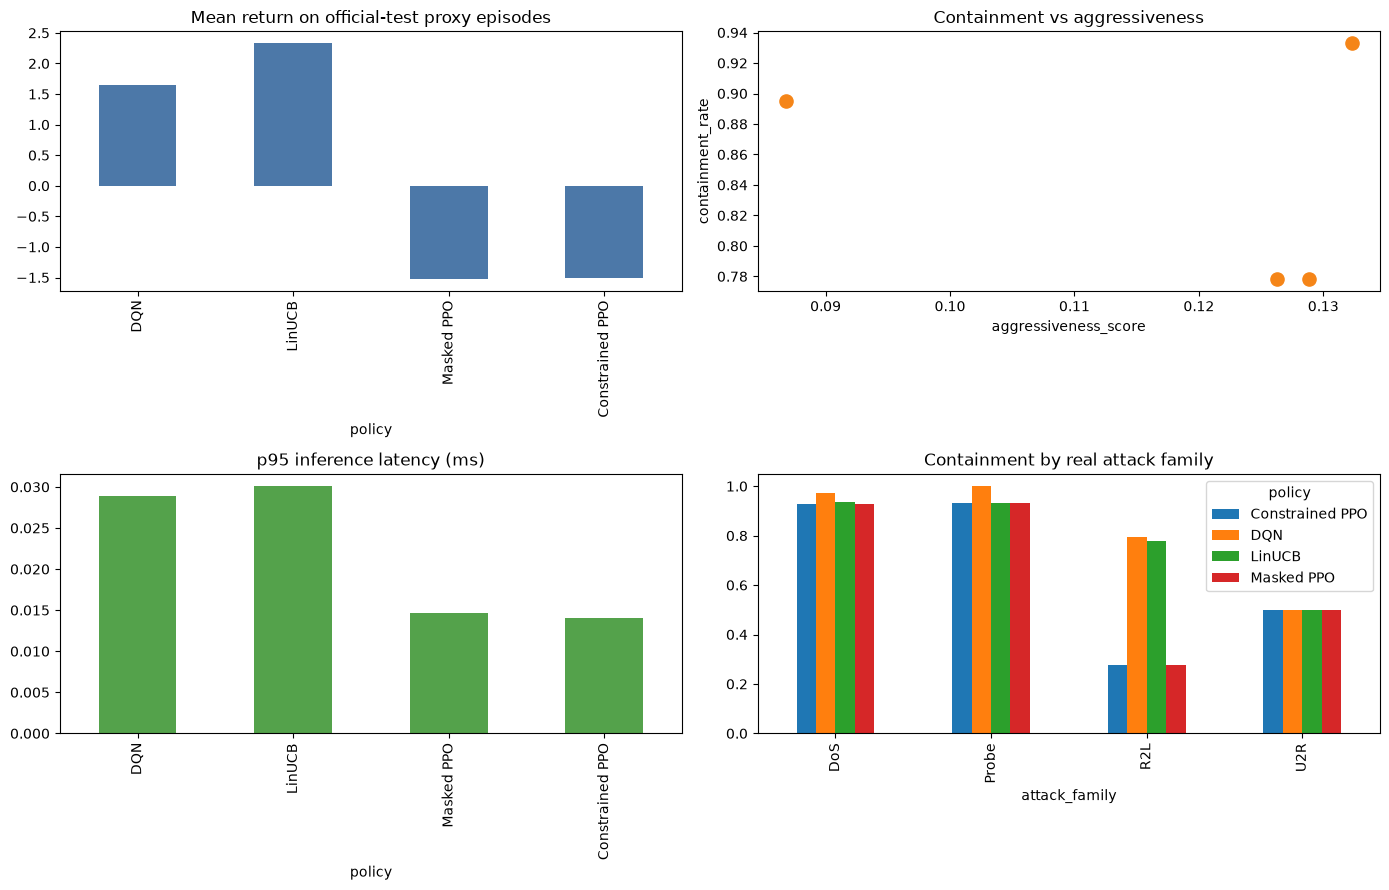

,professional evidence conclusion
dataset,NSL-KDD official split
sequence_evidence,proxy—not timestamped
detector_scoring,OOF train; train-only official test
best_calibration,raw
score_PSI,0.181841
best_return_policy,LinUCB
least_aggressive_policy,LinUCB
fastest_policy,Constrained PPO
all_constraints_passed,False
human_review_rate,0.0336


In [31]:
from ips.evidence_analysis import profile_policy
from ips.dataset_environment import DatasetBackedIpsEnv
sample_states=[]; sample_masks=[]
for index,episode in enumerate(nsl_evidence.splits.test[:100]):
    observation,info=DatasetBackedIpsEnv(episode,seed=SEED+index).reset(seed=SEED+index); sample_states.append(observation.as_array()); sample_masks.append(np.asarray(info['action_mask']))
resource_rows=[]
training_by_policy=pd.DataFrame(real_training_resources).set_index('policy')
for name,policy in real_policies.items():
    profile=profile_policy(policy,np.asarray(sample_states),np.asarray(sample_masks),repeats=30)
    if name=='DQN': parameters=sum(p.numel() for p in real_dqn.parameters()); model_mb=sum(p.numel()*p.element_size() for p in real_dqn.parameters())/1024**2
    elif name=='LinUCB': parameters=real_bandit.A.size+real_bandit.b.size; model_mb=(real_bandit.A.nbytes+real_bandit.b.nbytes)/1024**2
    else:
        model=real_ppo if name=='Masked PPO' else real_cppo; parameters=sum(p.numel() for p in model.parameters()); model_mb=sum(p.numel()*p.element_size() for p in model.parameters())/1024**2
    resource_rows.append({'policy':name,'parameters':parameters,'model_mb':model_mb,**training_by_policy.loc[name].to_dict(),**profile})
real_resource_comparison=pd.DataFrame(resource_rows)
severity={'ALLOW':0,'MONITOR':1,'RATE_LIMIT':2,'DROP_FLOW':3,'TEMP_BLOCK_SOURCE':4,'BLOCK_DESTINATION_PORT':5,'ISOLATE_HOST':6}
aggressiveness=(real_action_comparison.assign(weight=lambda x:x.action.map(severity),weighted=lambda x:x.fraction*x.weight).groupby('policy').weighted.sum()/6).rename('aggressiveness_score').reset_index()
operational=real_policy_comparison.merge(aggressiveness,on='policy').merge(real_resource_comparison[['policy','latency_p95_ms','throughput_decisions_s','model_mb','max_rss_mb']],on='policy')
operational['false_prevention_constraint']=operational.false_preventions_per_episode<0.01
operational['latency_constraint']=operational.latency_p95_ms<20.0
operational['constraints_passed']=operational[['false_prevention_constraint','latency_constraint']].all(axis=1)
operational['evidence_grade']='REAL DETECTOR / COUNTERFACTUAL IPS'
display(operational.round(4)); display(real_resource_comparison.round(4)); display(calibration_comparison.round(5)); display(drift_summary.round(5)); display(unseen_family_results.round(4))
real_output=OUTPUT/'real_nsl_evidence'; real_output.mkdir(parents=True,exist_ok=True)
operational.to_csv(real_output/'policy_operational_comparison.csv',index=False); real_resource_comparison.to_csv(real_output/'resource_consumption.csv',index=False)
real_family_comparison.to_csv(real_output/'attack_family_metrics.csv',index=False); real_action_comparison.to_csv(real_output/'action_distribution.csv',index=False)
calibration_comparison.to_csv(real_output/'calibration_comparison.csv',index=False); drift_summary.to_csv(real_output/'drift_summary.csv',index=False); unseen_family_results.to_csv(real_output/'unseen_family_results.csv',index=False)
fig,axes=plt.subplots(2,2,figsize=(14,9))
operational.plot.bar(x='policy',y='mean_return',ax=axes[0,0],legend=False,title='Mean return on official-test proxy episodes',color='#4c78a8')
operational.plot.scatter(x='aggressiveness_score',y='containment_rate',s=90,ax=axes[0,1],title='Containment vs aggressiveness',color='#f58518')
real_resource_comparison.plot.bar(x='policy',y='latency_p95_ms',ax=axes[1,0],legend=False,title='p95 inference latency (ms)',color='#54a24b')
real_family_comparison.pivot(index='attack_family',columns='policy',values='containment_rate').plot.bar(ax=axes[1,1],title='Containment by real attack family')
plt.tight_layout(); plt.show()
real_dashboard={'dataset':'NSL-KDD official split','sequence_evidence':'proxy—not timestamped','detector_scoring':'OOF train; train-only official test','best_calibration':calibration_comparison.iloc[0].method,'score_PSI':float(drift_summary.iloc[0].score_PSI),'best_return_policy':operational.sort_values('mean_return',ascending=False).iloc[0].policy,'least_aggressive_policy':operational.sort_values('aggressiveness_score').iloc[0].policy,'fastest_policy':real_resource_comparison.sort_values('latency_p95_ms').iloc[0].policy,'all_constraints_passed':bool(operational.constraints_passed.all()),'human_review_rate':float(escalation_summary.iloc[0].human_review_rate),'next_realism_gate':'timestamped CICIoT/CSE/TON traffic plus observed cyber-range interventions'}
(OUTPUT/'real_nsl_professional_dashboard.json').write_text(json.dumps(real_dashboard,indent=2)+'\n')
display(pd.Series(real_dashboard,name='professional evidence conclusion').to_frame())